# Exploratory Data Analysis
# Churn em empresa de Telecom

In [7]:
import os
import pandas as pd

print("[START] Loading Excel from raw folder")

RAW_DIR = r"C:\Repos\a3data-churn\data\raw"
print("[INFO] raw_dir:", RAW_DIR)
print("[INFO] raw_dir_exists:", os.path.isdir(RAW_DIR))

xlsx_files = []
if os.path.isdir(RAW_DIR):
    xlsx_files = [os.path.join(RAW_DIR, f) for f in os.listdir(RAW_DIR) if f.lower().endswith(".xlsx")]

print("[INFO] xlsx_files_count:", len(xlsx_files))
for p in sorted(xlsx_files)[:20]:
    print("[INFO] xlsx_file:", p)

if len(xlsx_files) == 0:
    raise FileNotFoundError(f"No .xlsx found in {RAW_DIR}")

XLSX_PATH = sorted(xlsx_files)[0]
print("[OK] XLSX_PATH:", XLSX_PATH)

SHEET = "Customer-Churn"
print("[INFO] sheet_selected:", SHEET)

df = pd.read_excel(XLSX_PATH, sheet_name=SHEET)

print("[OK] shape:", df.shape)
print("[OK] columns_count:", len(df.columns))
print("[OK] columns:", list(df.columns))
display(df.head(3))

[START] Loading Excel from raw folder
[INFO] raw_dir: C:\Repos\a3data-churn\data\raw
[INFO] raw_dir_exists: True
[INFO] xlsx_files_count: 1
[INFO] xlsx_file: C:\Repos\a3data-churn\data\raw\Customer-Churn.xlsx
[OK] XLSX_PATH: C:\Repos\a3data-churn\data\raw\Customer-Churn.xlsx
[INFO] sheet_selected: Customer-Churn
[OK] shape: (7043, 21)
[OK] columns_count: 21
[OK] columns: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7569-NMZYQ,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),118.75,8672.45,No
1,8984-HPEMB,Female,0,No,No,71,Yes,Yes,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Electronic check,118.65,8477.60,No
2,5989-AXPUC,Female,0,Yes,No,68,Yes,Yes,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,No,Mailed check,118.60,7990.05,No


In [8]:
import time
import json
import pandas as pd

t0 = time.time()

SHEET = "Customer-Churn"
print("sheet_selected:", SHEET)

df = pd.read_excel(XLSX_PATH, sheet_name=SHEET)

print("shape:", df.shape)
print("columns_count:", len(df.columns))
print("columns:", list(df.columns))


print("\ndtypes:")
print(json.dumps(df.dtypes.astype(str).to_dict(), ensure_ascii=False, indent=2))

print("\nmissing_values_top:")
miss = df.isna().sum().sort_values(ascending=False)
miss = miss[miss > 0]
print("none" if len(miss) == 0 else miss.head(30).to_string())

print("\nunique_counts_top:")
nun = df.nunique(dropna=False).sort_values()
print(nun.head(40).to_string())

elapsed = time.time() - t0
print("\nelapsed_s:", round(elapsed, 3))

sheet_selected: Customer-Churn
shape: (7043, 21)
columns_count: 21
columns: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

dtypes:
{
  "customerID": "object",
  "gender": "object",
  "SeniorCitizen": "int64",
  "Partner": "object",
  "Dependents": "object",
  "tenure": "int64",
  "PhoneService": "object",
  "MultipleLines": "object",
  "InternetService": "object",
  "OnlineSecurity": "object",
  "OnlineBackup": "object",
  "DeviceProtection": "object",
  "TechSupport": "object",
  "StreamingTV": "object",
  "StreamingMovies": "object",
  "Contract": "object",
  "PaperlessBilling": "object",
  "PaymentMethod": "object",
  "MonthlyCharges": "float64",
  "TotalCharges": "float64",
  "Churn": "object"
}

missing_valu

In [9]:
df.head(1)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7569-NMZYQ,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),118.75,8672.45,No


In [10]:
# Apenas a variável TotalCharges tem missing data.
# Temos diversas variáveis categóricas que para modelagem devemos transformar em variáveis dummy. Exemplo (No, Yes) vira (0,1).

In [11]:
import pandas as pd

print("shape:", df.shape)
print("columns_count:", len(df.columns))

print("\nChurn value_counts:")
print(df["Churn"].value_counts(dropna=False).to_string())

df["churn_flag"] = df["Churn"].astype(str).str.strip().str.lower().map({"yes": 1, "no": 0})
print("\nchurn_rate:", round(float(df["churn_flag"].mean()), 4))

shape: (7043, 21)
columns_count: 21

Churn value_counts:
Churn
No     5174
Yes    1869

churn_rate: 0.2654


Taxa de Churn acima de 25%

TotalCharges nulls before: 11


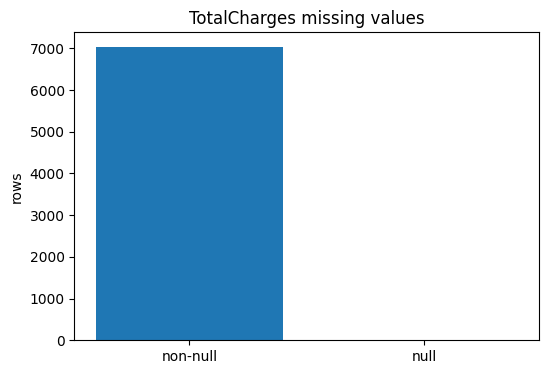

TotalCharges nulls after: 0


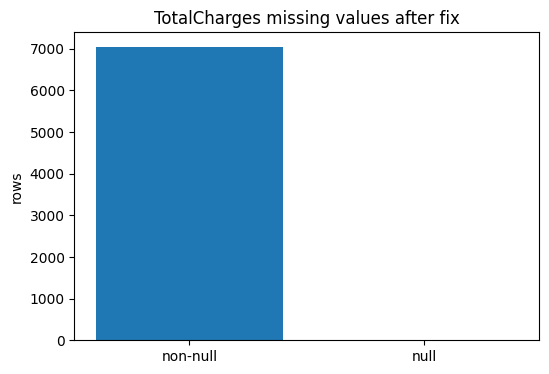


Fixed rows preview:
 tenure  MonthlyCharges  TotalCharges Churn
      0           80.85           0.0    No
      0           73.35           0.0    No
      0           61.90           0.0    No
      0           56.05           0.0    No
      0           52.55           0.0    No
      0           25.75           0.0    No
      0           25.35           0.0    No
      0           20.25           0.0    No
      0           20.00           0.0    No
      0           19.85           0.0    No
      0           19.70           0.0    No


In [12]:
import matplotlib.pyplot as plt

nulls_before = int(df["TotalCharges"].isna().sum())
print("TotalCharges nulls before:", nulls_before)

plt.figure(figsize=(6, 4))
plt.bar(["non-null", "null"], [int((~df["TotalCharges"].isna()).sum()), nulls_before])
plt.title("TotalCharges missing values")
plt.ylabel("rows")
plt.show()

mask_tc_null = df["TotalCharges"].isna()
if int(mask_tc_null.sum()) > 0:
    df.loc[mask_tc_null, "TotalCharges"] = df.loc[mask_tc_null, "MonthlyCharges"] * df.loc[mask_tc_null, "tenure"]

print("TotalCharges nulls after:", int(df["TotalCharges"].isna().sum()))

plt.figure(figsize=(6, 4))
plt.bar(["non-null", "null"], [int((~df["TotalCharges"].isna()).sum()), int(df["TotalCharges"].isna().sum())])
plt.title("TotalCharges missing values after fix")
plt.ylabel("rows")
plt.show()

print("\nFixed rows preview:")
print(df.loc[mask_tc_null, ["tenure", "MonthlyCharges", "TotalCharges", "Churn"]].head(20).to_string(index=False))

In [13]:
# Traramento do Null. Foi transformado em 0

counts_no: 5174
counts_yes: 1869
churn_rate: 0.2654


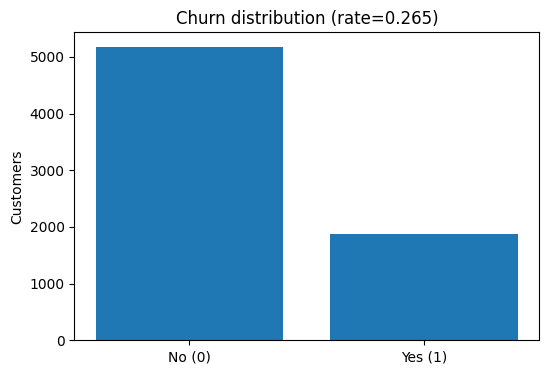

In [14]:
import matplotlib.pyplot as plt

counts = df["churn_flag"].value_counts().sort_index()
labels = ["No (0)", "Yes (1)"]
values = [int(counts.get(0, 0)), int(counts.get(1, 0))]
rate = float(df["churn_flag"].mean())

print("counts_no:", values[0])
print("counts_yes:", values[1])
print("churn_rate:", round(rate, 4))

plt.figure(figsize=(6, 4))
plt.bar(labels, values)
plt.title(f"Churn distribution (rate={rate:.3f})")
plt.ylabel("Customers")
plt.show()

In [15]:
# Distribuição do Churn. Acima de 25% como comentado anteriormente.

      Contract     mean  count
Month-to-month 0.427097   3875
      One year 0.112695   1473
      Two year 0.028319   1695


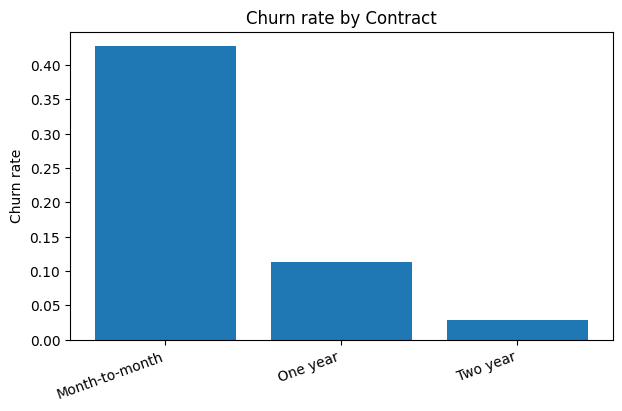

In [16]:
import matplotlib.pyplot as plt

tmp = df.groupby("Contract", dropna=False)["churn_flag"].agg(["mean", "count"]).reset_index()
tmp = tmp.sort_values("mean", ascending=False)

print(tmp.to_string(index=False))

plt.figure(figsize=(7, 4))
plt.bar(tmp["Contract"].astype(str), tmp["mean"])
plt.title("Churn rate by Contract")
plt.ylabel("Churn rate")
plt.xticks(rotation=20, ha="right")
plt.show()

In [17]:
# Podemos perceber que a medida que o tempo de fidelidade aumenta a taxa de churn diminui. Isso é natural e pode indicar uma possível estratégia para diminuir o churn que seja converter as pessoas que estão em contratos de curto prazo para contratos de longo prazo.

tenure_band     mean  count
        0-6 0.529372   1481
       7-12 0.358865    705
      13-24 0.287109   1024
      25-48 0.203890   1594
        49+ 0.095132   2239


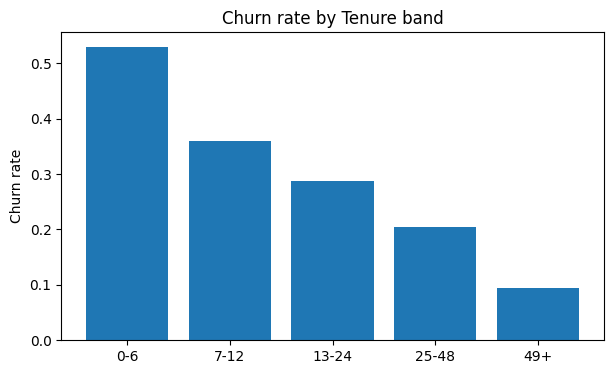

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

bins = [-1, 6, 12, 24, 48, 1000]
labels = ["0-6", "7-12", "13-24", "25-48", "49+"]

df["tenure_band"] = pd.cut(df["tenure"], bins=bins, labels=labels)

tmp = df.groupby("tenure_band", dropna=False, observed=False)["churn_flag"].agg(["mean", "count"]).reset_index()
print(tmp.to_string(index=False))

plt.figure(figsize=(7, 4))
plt.bar(tmp["tenure_band"].astype(str), tmp["mean"])
plt.title("Churn rate by Tenure band")
plt.ylabel("Churn rate")
plt.show()

In [19]:
# Maior risco de churn nos primeiros meses. Verificar possíveis estratégias de onboarding.

            PaymentMethod     mean  count
         Electronic check 0.452854   2365
             Mailed check 0.191067   1612
Bank transfer (automatic) 0.167098   1544
  Credit card (automatic) 0.152431   1522


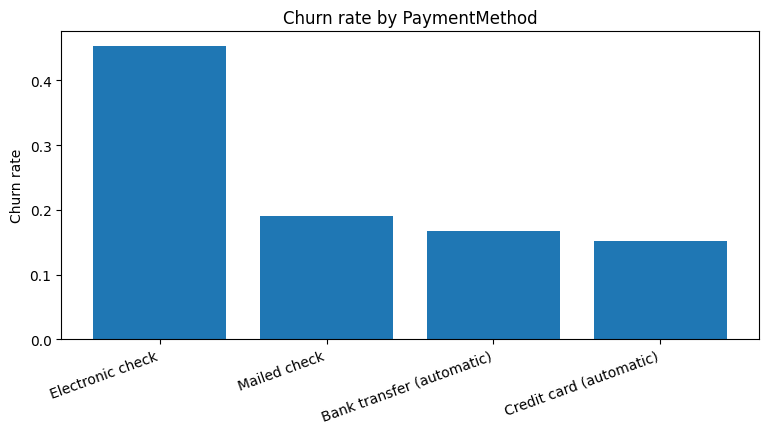

In [20]:
import matplotlib.pyplot as plt

tmp = df.groupby("PaymentMethod", dropna=False)["churn_flag"].agg(["mean", "count"]).reset_index()
tmp = tmp.sort_values("mean", ascending=False)

print(tmp.to_string(index=False))

plt.figure(figsize=(9, 4))
plt.bar(tmp["PaymentMethod"].astype(str), tmp["mean"])
plt.title("Churn rate by PaymentMethod")
plt.ylabel("Churn rate")
plt.xticks(rotation=20, ha="right")
plt.show()

In [21]:
# Podemos perceber que o método de pagamento eletrônico tem significativamente mais churn do que os outros métodos.

InternetService     mean  count
    Fiber optic 0.418928   3096
            DSL 0.189591   2421
             No 0.074050   1526


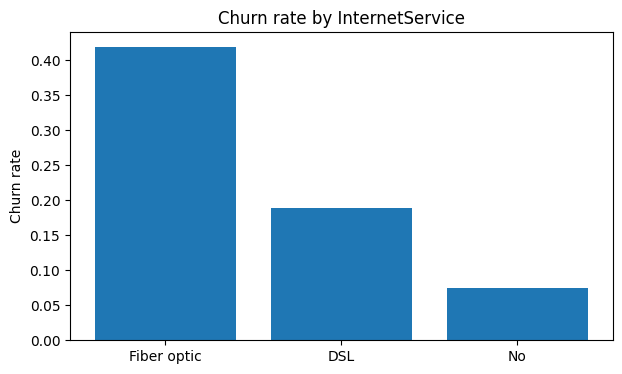

In [22]:
import matplotlib.pyplot as plt

tmp = df.groupby("InternetService", dropna=False)["churn_flag"].agg(["mean", "count"]).reset_index()
tmp = tmp.sort_values("mean", ascending=False)

print(tmp.to_string(index=False))

plt.figure(figsize=(7, 4))
plt.bar(tmp["InternetService"].astype(str), tmp["mean"])
plt.title("Churn rate by InternetService")
plt.ylabel("Churn rate")
plt.show()

In [23]:
# Também podemos perceber que a fibra ótica é o maior agressor do churn.


col: OnlineSecurity
     OnlineSecurity     mean  count
                 No 0.417667   3498
                Yes 0.146112   2019
No internet service 0.074050   1526


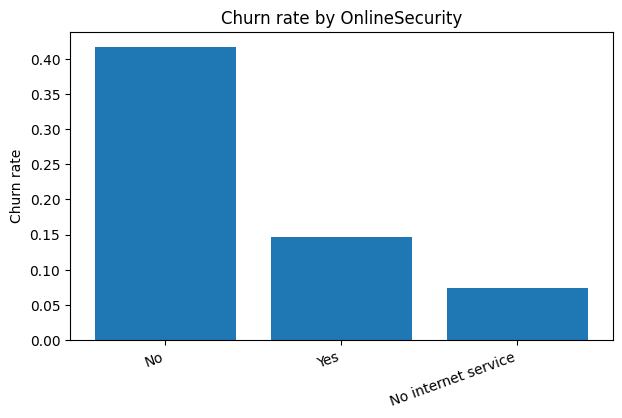


col: TechSupport
        TechSupport     mean  count
                 No 0.416355   3473
                Yes 0.151663   2044
No internet service 0.074050   1526


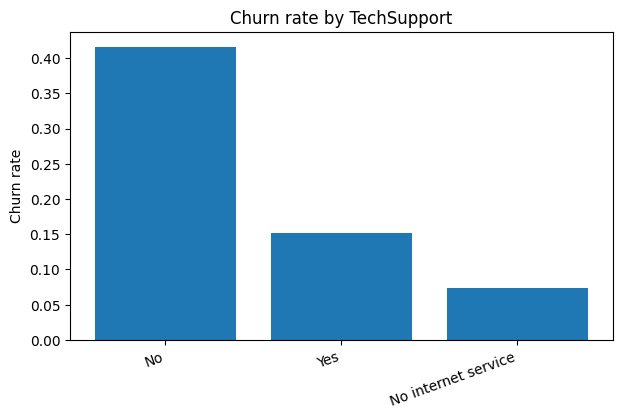

In [24]:
import matplotlib.pyplot as plt

for col in ["OnlineSecurity", "TechSupport"]:
    tmp = df.groupby(col, dropna=False)["churn_flag"].agg(["mean", "count"]).reset_index()
    tmp = tmp.sort_values("mean", ascending=False)

    print("\n" + "=" * 80)
    print("col:", col)
    print(tmp.to_string(index=False))

    plt.figure(figsize=(7, 4))
    plt.bar(tmp[col].astype(str), tmp["mean"])
    plt.title(f"Churn rate by {col}")
    plt.ylabel("Churn rate")
    plt.xticks(rotation=20, ha="right")
    plt.show()

[INFO] counts_no_yes: 5174 1869
[INFO] churn_share_yes_pct: 26.54
[SUMMARY] Monthly charges distribution by churn
[SUMMARY] no_churn: {'n': 5174, 'p05': 19.6, 'p25': 25.1, 'p50': 64.42500000000001, 'p75': 88.4, 'p95': 108.41749999999998}
[SUMMARY] churn: {'n': 1869, 'p05': 20.62, 'p25': 56.15, 'p50': 79.65, 'p75': 94.2, 'p95': 105.61}
[SUMMARY] median_delta (churn - no_churn): 15.225


C:\Users\Usuario\AppData\Local\Temp\ipykernel_17940\1279312634.py:32: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


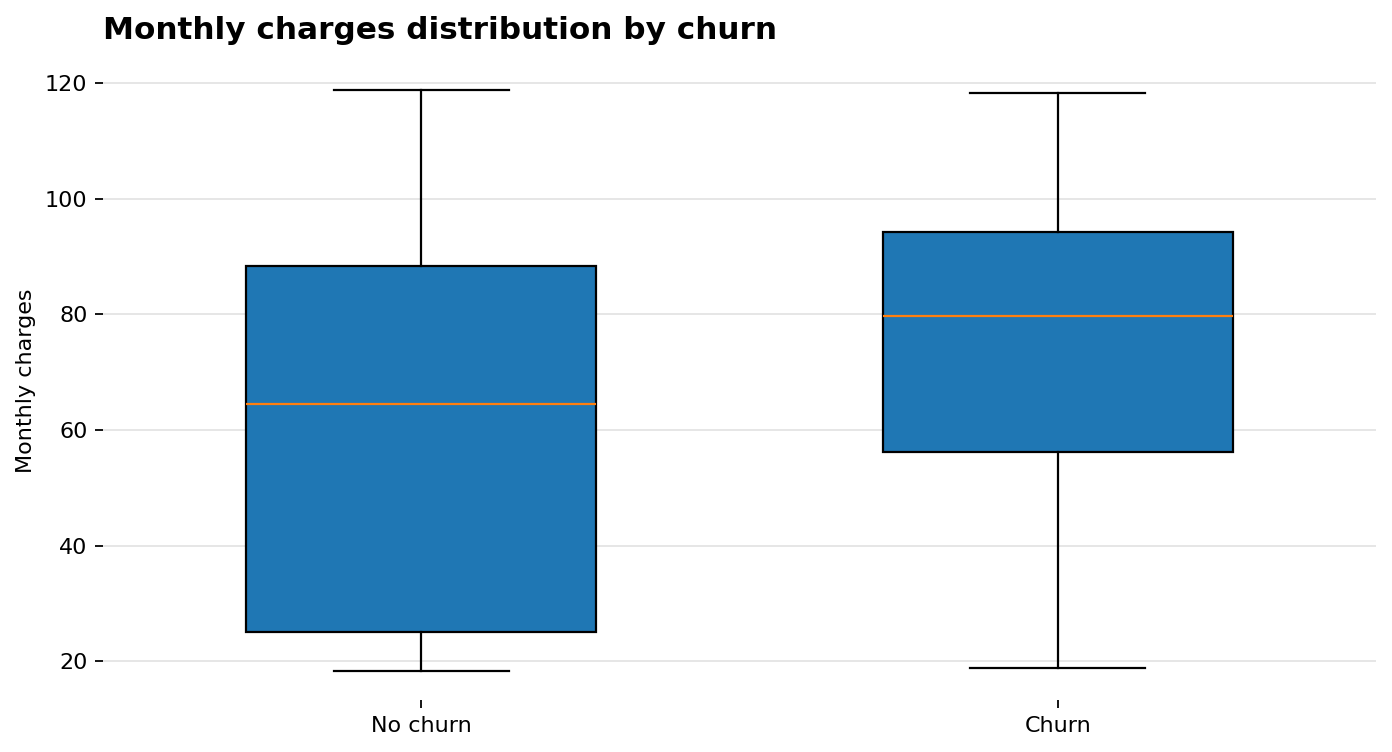

[SUMMARY] Tenure distribution by churn
[SUMMARY] no_churn: {'n': 5174, 'p05': 2.0, 'p25': 15.0, 'p50': 38.0, 'p75': 61.0, 'p95': 72.0}
[SUMMARY] churn: {'n': 1869, 'p05': 1.0, 'p25': 2.0, 'p50': 10.0, 'p75': 29.0, 'p95': 60.0}
[SUMMARY] median_delta (churn - no_churn): -28.0


C:\Users\Usuario\AppData\Local\Temp\ipykernel_17940\1279312634.py:32: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


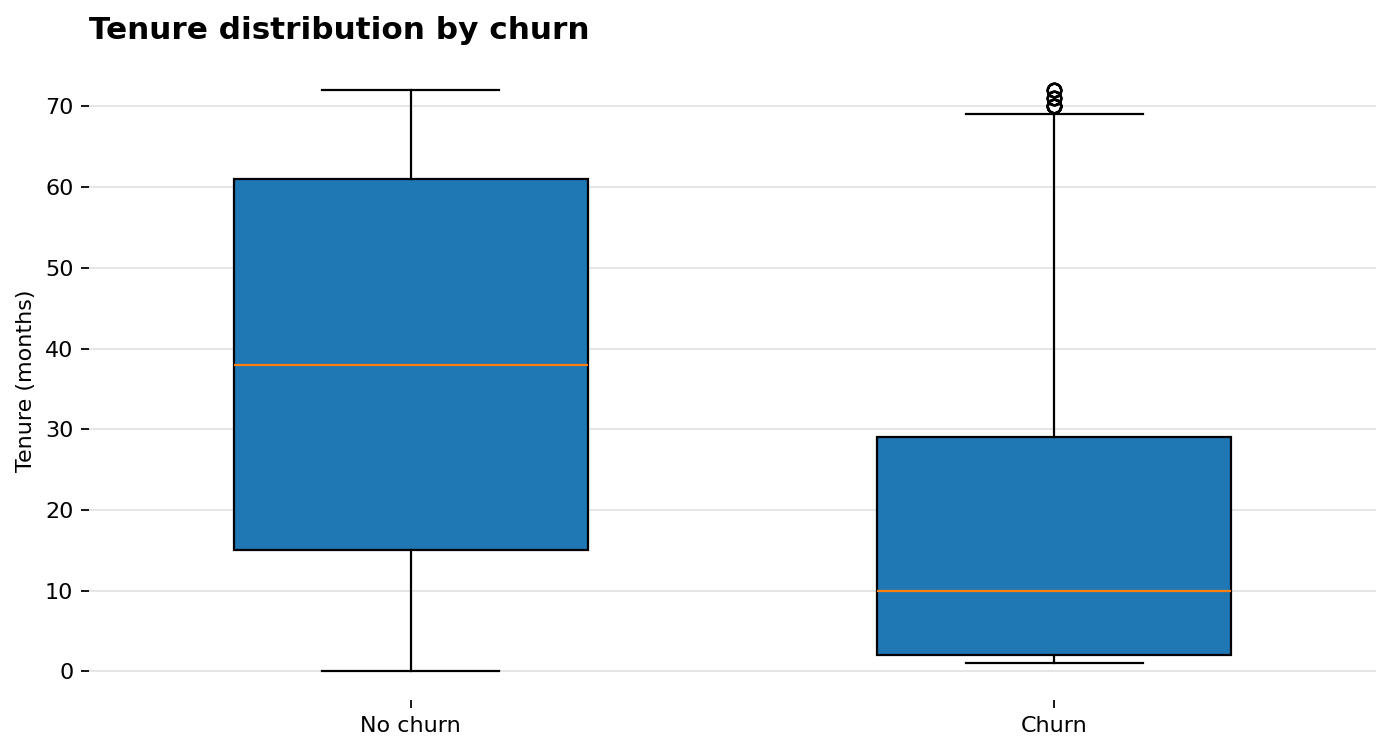

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df_no = df[df["churn_flag"] == 0]
df_yes = df[df["churn_flag"] == 1]

n_no = int(df_no.shape[0])
n_yes = int(df_yes.shape[0])
n_total = n_no + n_yes

print("[INFO] counts_no_yes:", n_no, n_yes)
print("[INFO] churn_share_yes_pct:", round(100 * n_yes / n_total, 2) if n_total > 0 else None)

def _five_num(s):
    s = pd.to_numeric(s, errors="coerce").dropna()
    if s.shape[0] == 0:
        return None
    return {
        "n": int(s.shape[0]),
        "p05": float(np.percentile(s, 5)),
        "p25": float(np.percentile(s, 25)),
        "p50": float(np.percentile(s, 50)),
        "p75": float(np.percentile(s, 75)),
        "p95": float(np.percentile(s, 95)),
    }

def _exec_box(ax, data_no, data_yes, y_label, title):
    data_no = pd.to_numeric(data_no, errors="coerce").dropna()
    data_yes = pd.to_numeric(data_yes, errors="coerce").dropna()

    ax.boxplot(
        [data_no, data_yes],
        labels=["No churn", "Churn"],
        showfliers=True,
        whis=1.5,
        widths=0.55,
        patch_artist=True
    )

    for spine in ax.spines.values():
        spine.set_visible(False)

    ax.grid(axis="y", linestyle="-", linewidth=0.8, alpha=0.35)
    ax.set_axisbelow(True)
    ax.set_ylabel(y_label)
    ax.set_title(title, loc="left", fontsize=14, fontweight="bold", pad=10)

    s0 = _five_num(data_no)
    s1 = _five_num(data_yes)

    if (s0 is not None) and (s1 is not None):
        print("[SUMMARY]", title)
        print("[SUMMARY] no_churn:", s0)
        print("[SUMMARY] churn:", s1)
        print("[SUMMARY] median_delta (churn - no_churn):", round(s1["p50"] - s0["p50"], 4))

fig, ax = plt.subplots(figsize=(8.8, 4.8), dpi=160)
_exec_box(
    ax=ax,
    data_no=df_no["MonthlyCharges"],
    data_yes=df_yes["MonthlyCharges"],
    y_label="Monthly charges",
    title="Monthly charges distribution by churn"
)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8.8, 4.8), dpi=160)
_exec_box(
    ax=ax,
    data_no=df_no["tenure"],
    data_yes=df_yes["tenure"],
    y_label="Tenure (months)",
    title="Tenure distribution by churn"
)
plt.tight_layout()
plt.show()

In [26]:
# Sobre o MonthlyCharges podemos perceber que na mediana quem paga uma fatura maior tende a dar mais churn. Vale pensar estratégias de promoções para clientes que estiverem querendo cancelar.

# Assim como já haviamos verificado anteriormente podemos perceber que a propensão de churn é maior nos primeiros meses.
# Todavia, vale analisar os outliers: há clientes que, mesmo após muitos meses de fidelidade, decidem cancelar. Vale investigar esse grupo de clientes antigos que deram churn.

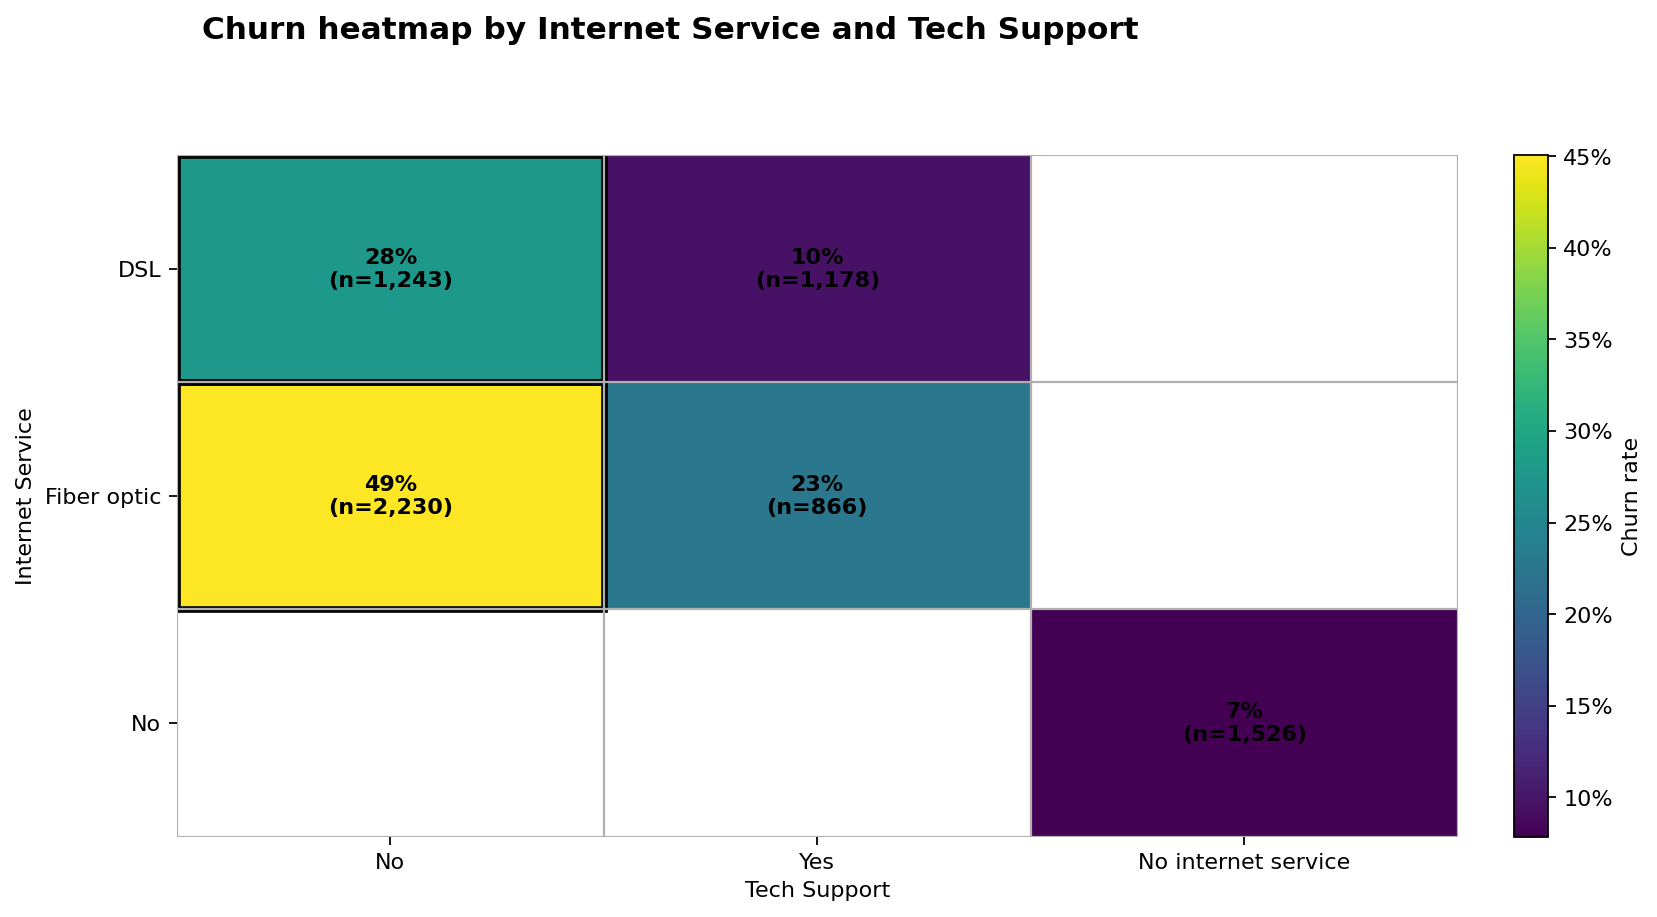

churn_rate (%):
TechSupport          No     Yes No internet service
InternetService                                    
DSL              27.76%   9.68%                 N/A
Fiber optic      49.37%  22.63%                 N/A
No                  N/A     N/A               7.40%

counts:
TechSupport        No   Yes  No internet service
InternetService                                 
DSL              1243  1178                    0
Fiber optic      2230   866                    0
No                  0     0                 1526


C:\Users\Usuario\AppData\Local\Temp\ipykernel_17940\3124860286.py:86: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  print(pivot_rate.applymap(lambda x: f"{x*100:.2f}%" if pd.notna(x) else "N/A").to_string())


In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

a = "InternetService"
b = "TechSupport"
value_col = "churn_flag"

row_order = ["DSL", "Fiber optic", "No"]
col_order = ["No", "Yes", "No internet service"]

pivot_rate = df.pivot_table(values=value_col, index=a, columns=b, aggfunc="mean").reindex(index=row_order, columns=col_order)
pivot_cnt = df.pivot_table(values=value_col, index=a, columns=b, aggfunc="count").reindex(index=row_order, columns=col_order)

rate = pivot_rate.to_numpy(dtype=float)
cnt = pivot_cnt.to_numpy(dtype=float)

valid = np.isfinite(rate)
if valid.sum() == 0:
    raise ValueError("No valid churn rates found. Check churn_flag or category values.")

vmin = float(np.nanpercentile(rate[valid], 5))
vmax = float(np.nanpercentile(rate[valid], 95))
if vmin == vmax:
    vmin = float(np.nanmin(rate[valid]))
    vmax = float(np.nanmax(rate[valid]))
if vmin == vmax:
    vmin = 0.0
    vmax = max(0.1, vmax)

flat = []
for i in range(rate.shape[0]):
    for j in range(rate.shape[1]):
        if np.isfinite(rate[i, j]) and np.isfinite(cnt[i, j]):
            flat.append((i, j, float(rate[i, j]), int(cnt[i, j])))

flat_sorted = sorted(flat, key=lambda x: x[2], reverse=True)
top_k = min(2, len(flat_sorted))
top_cells = set((flat_sorted[k][0], flat_sorted[k][1]) for k in range(top_k))

masked = np.ma.masked_invalid(rate)

fig, ax = plt.subplots(figsize=(10.5, 5.8), dpi=160)

im = ax.imshow(masked, aspect="auto", vmin=vmin, vmax=vmax)

ax.set_xticks(np.arange(len(col_order)))
ax.set_yticks(np.arange(len(row_order)))
ax.set_xticklabels(col_order)
ax.set_yticklabels(row_order)

ax.set_xlabel("Tech Support")
ax.set_ylabel("Internet Service")

for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_xticks(np.arange(-0.5, len(col_order), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(row_order), 1), minor=True)
ax.grid(which="minor", linestyle="-", linewidth=1.0)
ax.tick_params(which="minor", bottom=False, left=False)

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Churn rate")
cbar.ax.yaxis.set_major_formatter(PercentFormatter(xmax=1.0, decimals=0))

for i in range(len(row_order)):
    for j in range(len(col_order)):
        r = rate[i, j]
        n = cnt[i, j]
        if not np.isfinite(r) or not np.isfinite(n):
            label = ""
        else:
            label = f"{r*100:.0f}%\n(n={int(n):,})"
        ax.text(j, i, label, ha="center", va="center", fontsize=10, fontweight="semibold")
        if (i, j) in top_cells:
            ax.add_patch(plt.Rectangle((j - 0.5, i - 0.5), 1, 1, fill=False, linewidth=3.0))

fig.suptitle("Churn heatmap by Internet Service and Tech Support", x=0.125, ha="left", fontsize=14, fontweight="bold", y=0.98)

plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

print("churn_rate (%):")
print(pivot_rate.applymap(lambda x: f"{x*100:.2f}%" if pd.notna(x) else "N/A").to_string())

print("\ncounts:")
print(pivot_cnt.fillna(0).astype(int).to_string())

In [30]:
# Clientes com fibra óptica e sem suporte técnico apresentam maior propensão ao churn.

early_tenure     mean  count
  0-6 months 0.529372   1481
   7+ months 0.195074   5562


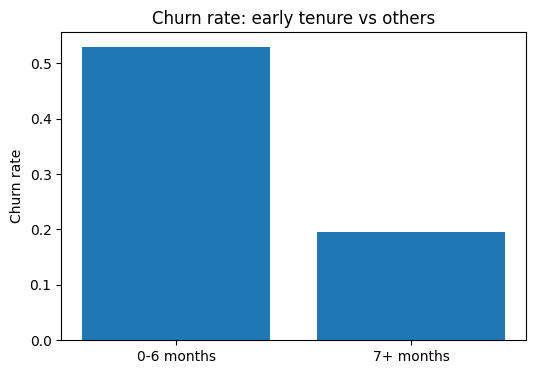

In [28]:
import matplotlib.pyplot as plt
import pandas as pd

df["early_tenure"] = (df["tenure"] <= 6).map({True: "0-6 months", False: "7+ months"})

tmp = df.groupby("early_tenure")["churn_flag"].agg(["mean", "count"]).reset_index()
tmp = tmp.sort_values("mean", ascending=False)

print(tmp.to_string(index=False))

plt.figure(figsize=(6, 4))
plt.bar(tmp["early_tenure"], tmp["mean"])
plt.title("Churn rate: early tenure vs others")
plt.ylabel("Churn rate")
plt.show()

In [ ]:
# Já haviamos verificado esse padrão. Apenas separando entre early vs others.

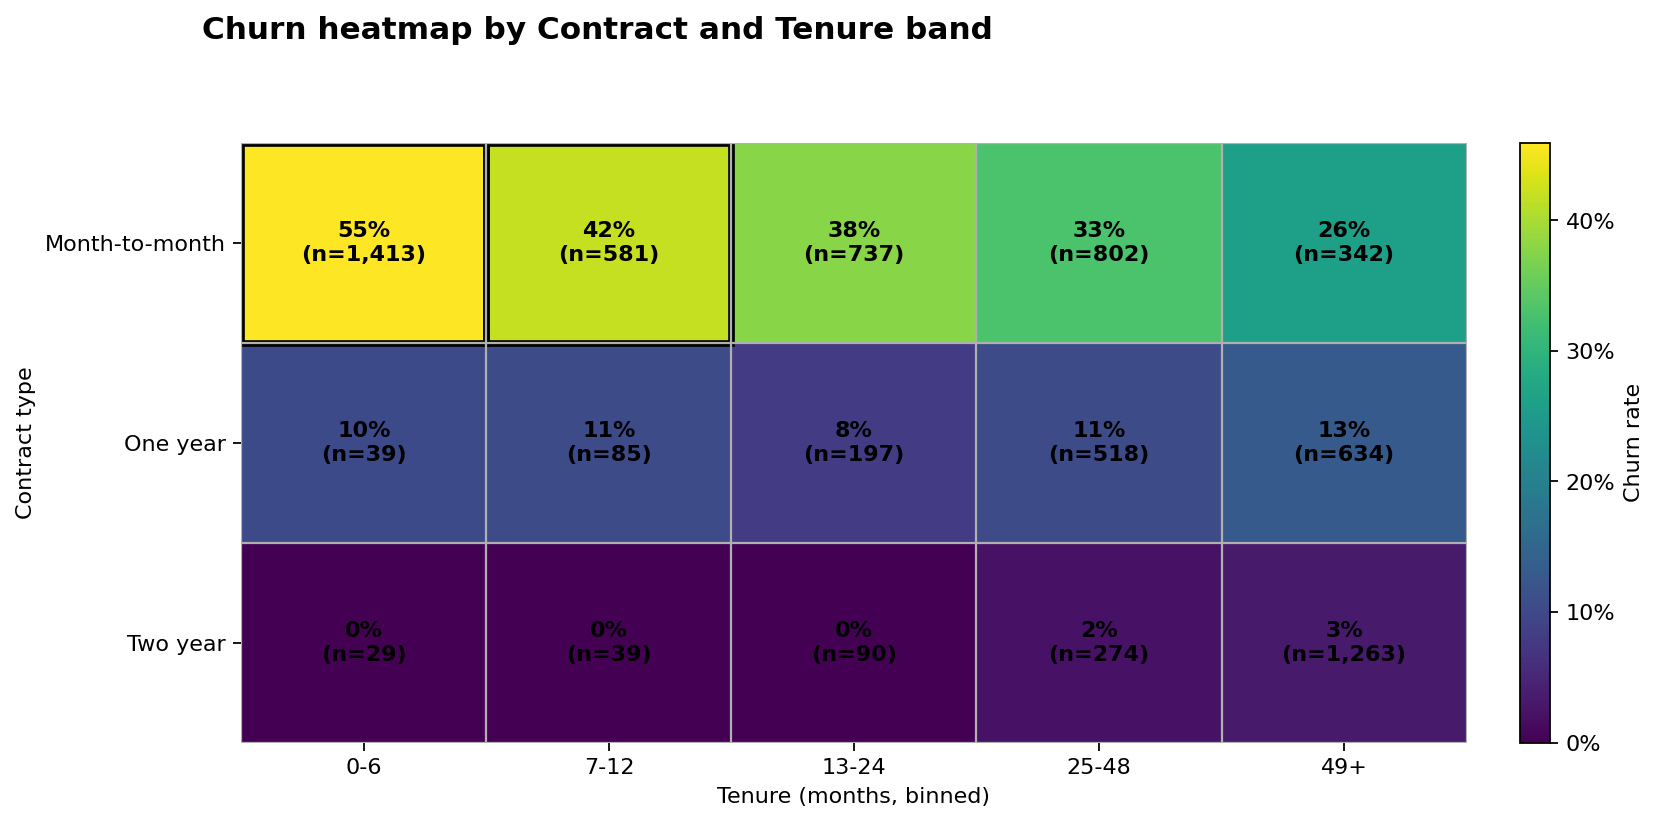

churn_rate (%):
tenure_band        0-6    7-12   13-24   25-48     49+
Contract                                              
Month-to-month  55.20%  42.00%  37.72%  32.92%  26.02%
One year        10.26%  10.59%   8.12%  10.62%  12.93%
Two year         0.00%   0.00%   0.00%   2.19%   3.33%

counts:
tenure_band      0-6  7-12  13-24  25-48   49+
Contract                                      
Month-to-month  1413   581    737    802   342
One year          39    85    197    518   634
Two year          29    39     90    274  1263


C:\Users\Usuario\AppData\Local\Temp\ipykernel_17940\4118105378.py:90: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  print(pivot_rate.applymap(lambda x: f"{x*100:.2f}%" if pd.notna(x) else "N/A").to_string())


In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

bins = [-1, 6, 12, 24, 48, 10**9]
labels = ["0-6", "7-12", "13-24", "25-48", "49+"]

df["tenure_band"] = pd.cut(df["tenure"], bins=bins, labels=labels)

a = "Contract"
b = "tenure_band"
value_col = "churn_flag"

row_order = ["Month-to-month", "One year", "Two year"]
col_order = labels

pivot_rate = df.pivot_table(values=value_col, index=a, columns=b, aggfunc="mean", observed=False).reindex(index=row_order, columns=col_order)
pivot_cnt = df.pivot_table(values=value_col, index=a, columns=b, aggfunc="count", observed=False).reindex(index=row_order, columns=col_order)

rate = pivot_rate.to_numpy(dtype=float)
cnt = pivot_cnt.to_numpy(dtype=float)

valid = np.isfinite(rate)
if valid.sum() == 0:
    raise ValueError("No valid churn rates found. Check churn_flag or tenure/contract values.")

vmin = float(np.nanpercentile(rate[valid], 5))
vmax = float(np.nanpercentile(rate[valid], 95))
if vmin == vmax:
    vmin = float(np.nanmin(rate[valid]))
    vmax = float(np.nanmax(rate[valid]))
if vmin == vmax:
    vmin = 0.0
    vmax = max(0.1, vmax)

flat = []
for i in range(rate.shape[0]):
    for j in range(rate.shape[1]):
        if np.isfinite(rate[i, j]) and np.isfinite(cnt[i, j]):
            flat.append((i, j, float(rate[i, j]), int(cnt[i, j])))

flat_sorted = sorted(flat, key=lambda x: x[2], reverse=True)
top_k = min(2, len(flat_sorted))
top_cells = set((flat_sorted[k][0], flat_sorted[k][1]) for k in range(top_k))

masked = np.ma.masked_invalid(rate)

fig, ax = plt.subplots(figsize=(10.5, 5.2), dpi=160)
im = ax.imshow(masked, aspect="auto", vmin=vmin, vmax=vmax)

ax.set_xticks(np.arange(len(col_order)))
ax.set_yticks(np.arange(len(row_order)))
ax.set_xticklabels(col_order)
ax.set_yticklabels(row_order)

ax.set_xlabel("Tenure (months, binned)")
ax.set_ylabel("Contract type")

for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_xticks(np.arange(-0.5, len(col_order), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(row_order), 1), minor=True)
ax.grid(which="minor", linestyle="-", linewidth=1.0)
ax.tick_params(which="minor", bottom=False, left=False)

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Churn rate")
cbar.ax.yaxis.set_major_formatter(PercentFormatter(xmax=1.0, decimals=0))

for i in range(len(row_order)):
    for j in range(len(col_order)):
        r = rate[i, j]
        n = cnt[i, j]
        if not np.isfinite(r) or not np.isfinite(n):
            label = ""
        else:
            label = f"{r*100:.0f}%\n(n={int(n):,})"
        ax.text(j, i, label, ha="center", va="center", fontsize=10, fontweight="semibold")
        if (i, j) in top_cells:
            ax.add_patch(plt.Rectangle((j - 0.5, i - 0.5), 1, 1, fill=False, linewidth=3.0))

fig.suptitle("Churn heatmap by Contract and Tenure band", x=0.125, ha="left", fontsize=14, fontweight="bold", y=0.98)

plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

print("churn_rate (%):")
print(pivot_rate.applymap(lambda x: f"{x*100:.2f}%" if pd.notna(x) else "N/A").to_string())

print("\ncounts:")
print(pivot_cnt.fillna(0).astype(int).to_string())

Como já haviamos verificado as maiores propensões de churn ocorrem nos primeiros meses dos contratos curtos 


[START] Executive churn bar charts
[INFO] cols: ['gender', 'SeniorCitizen', 'Partner', 'Dependents']
[INFO] col: gender
[INFO] groups: 2
[INFO] total_n: 7043
[INFO] churn_rate_overall: 0.2653698707936959


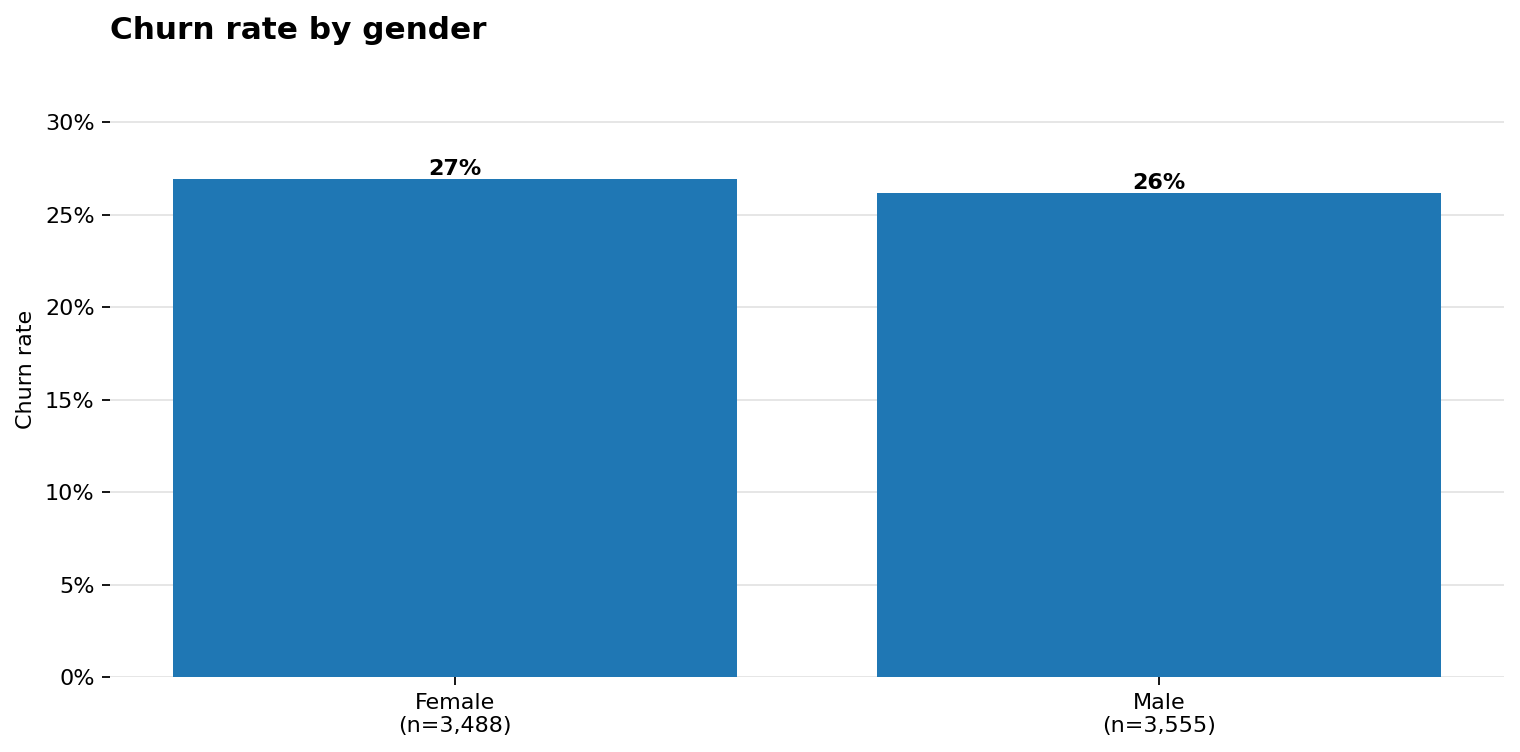


gender
gender mean_pct  count
Female   26.92%   3488
  Male   26.16%   3555
[INFO] col: SeniorCitizen
[INFO] groups: 2
[INFO] total_n: 7043
[INFO] churn_rate_overall: 0.2653698707936959


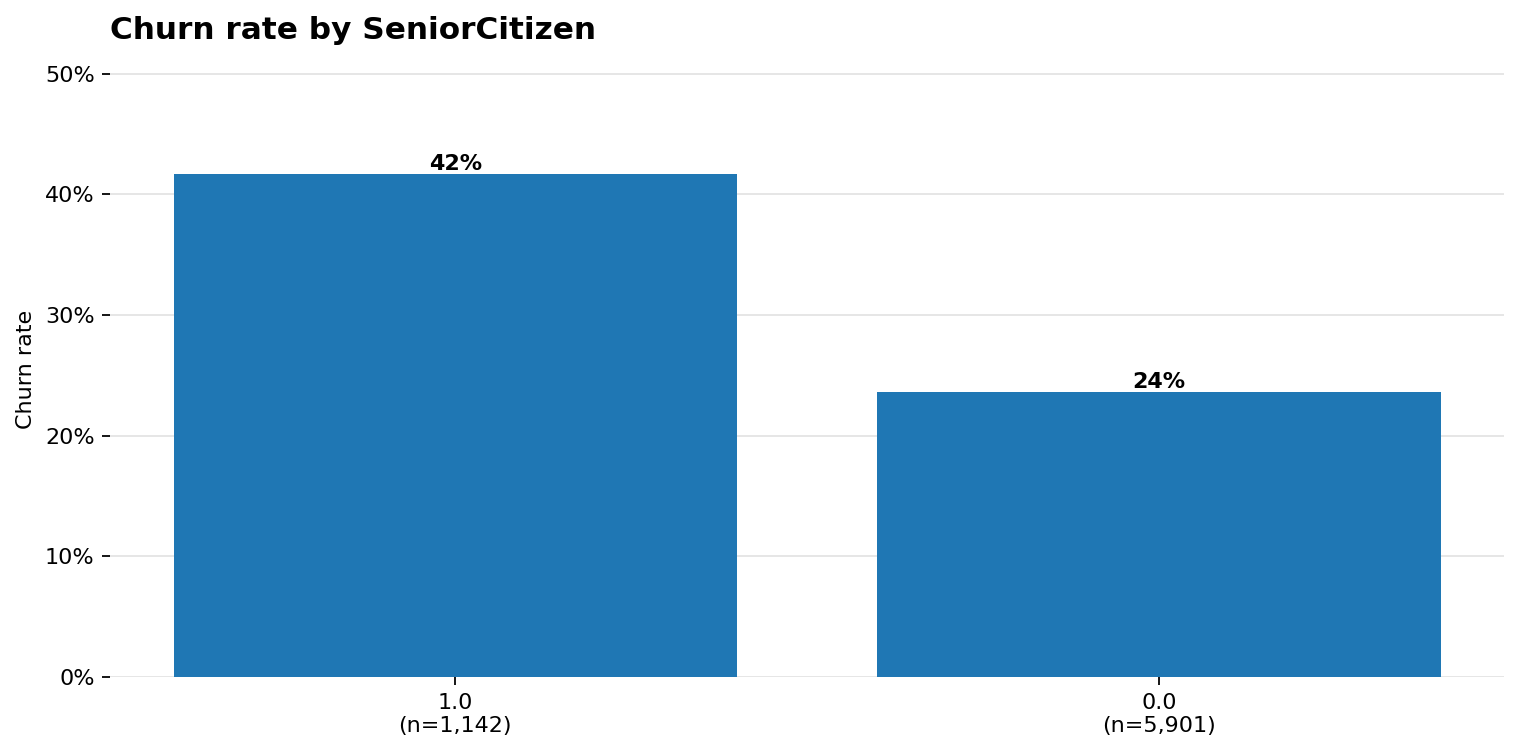


SeniorCitizen
 SeniorCitizen mean_pct  count
             1   41.68%   1142
             0   23.61%   5901
[INFO] col: Partner
[INFO] groups: 2
[INFO] total_n: 7043
[INFO] churn_rate_overall: 0.2653698707936959


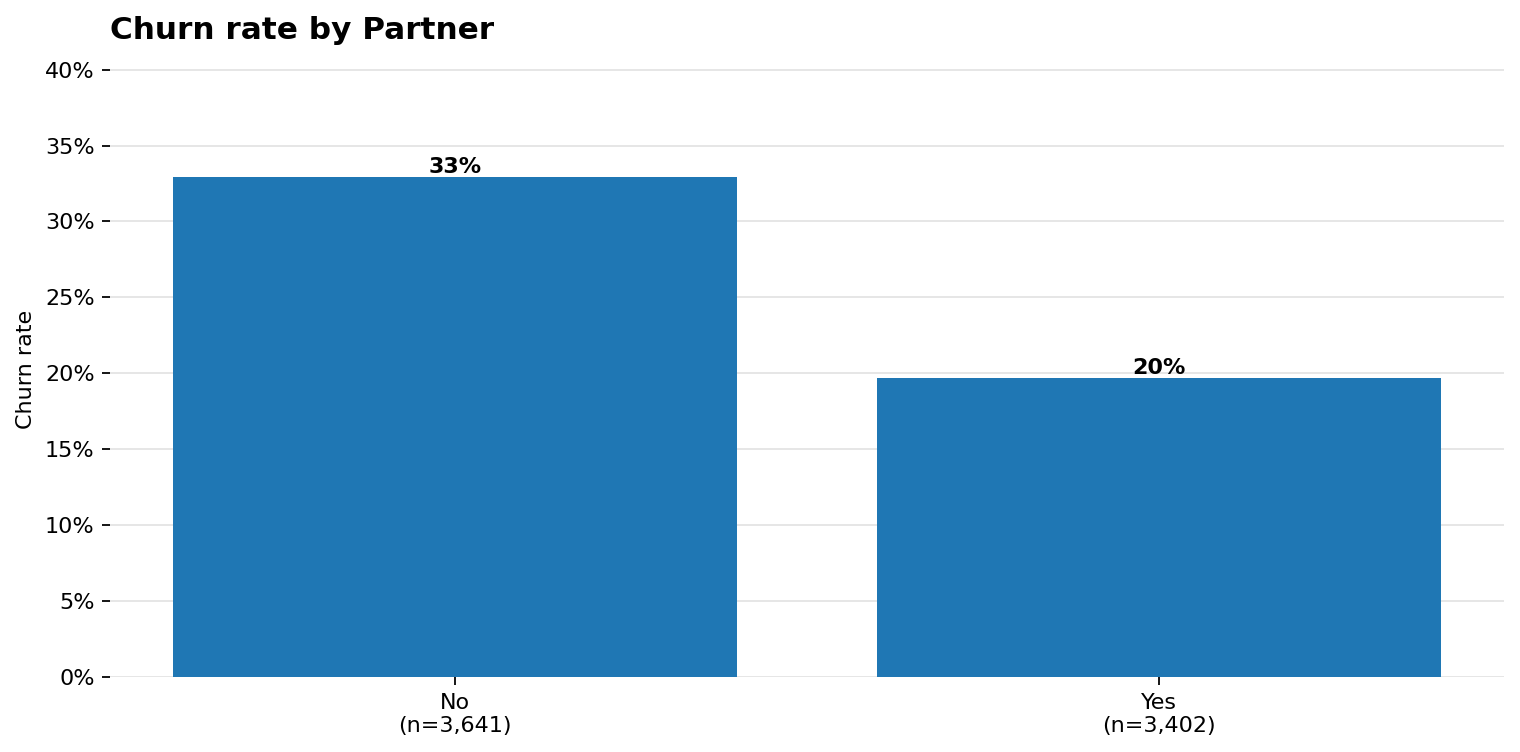


Partner
Partner mean_pct  count
     No   32.96%   3641
    Yes   19.66%   3402
[INFO] col: Dependents
[INFO] groups: 2
[INFO] total_n: 7043
[INFO] churn_rate_overall: 0.2653698707936959


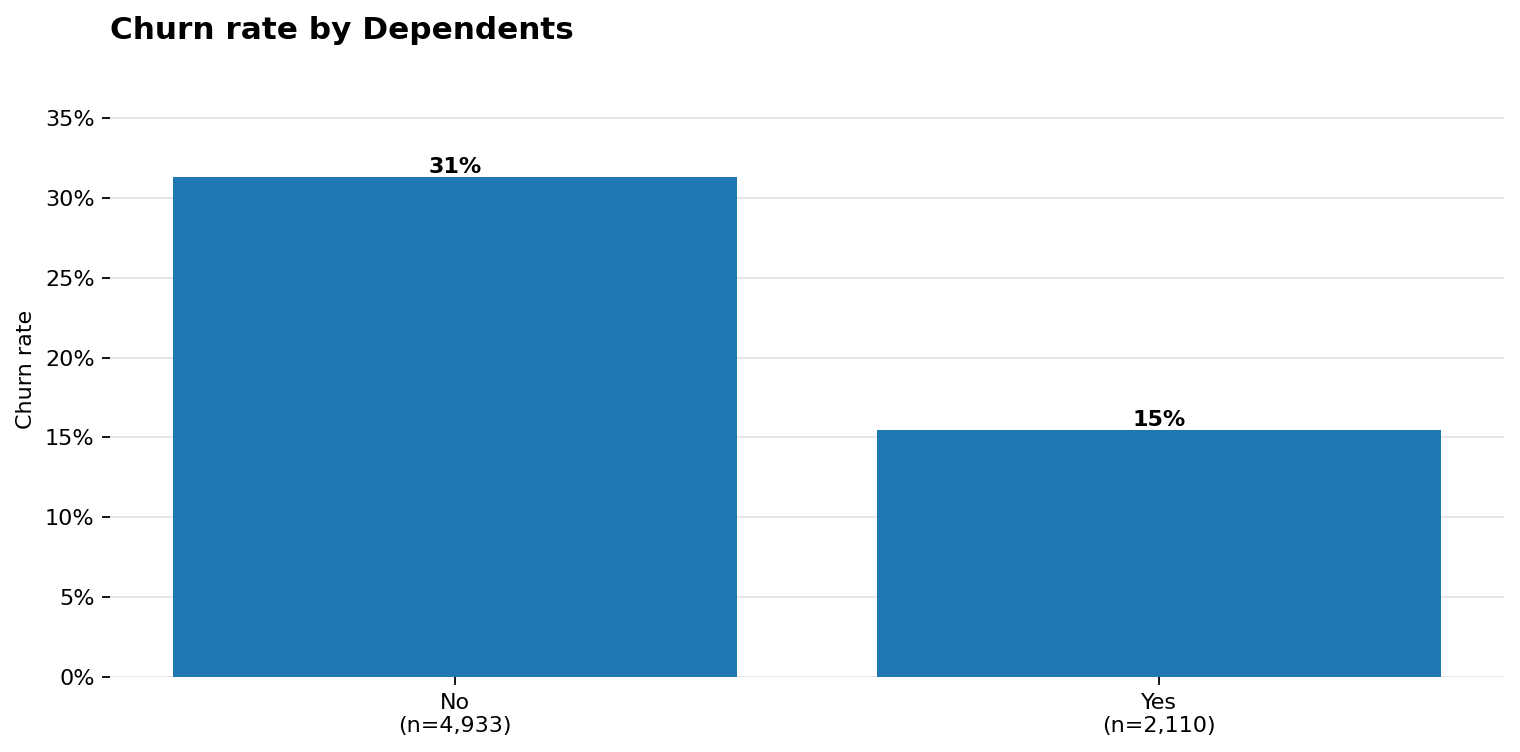


Dependents
Dependents mean_pct  count
        No   31.28%   4933
       Yes   15.45%   2110
[DONE] Executive churn bar charts


In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

cols = ["gender", "SeniorCitizen", "Partner", "Dependents"]

print("[START] Executive churn bar charts")
print("[INFO] cols:", cols)

def _safe_str(x):
    if pd.isna(x):
        return "Missing"
    return str(x)

def _exec_bar_churn_rate_by_col(df_in, col):
    tmp = df_in.groupby(col, dropna=False)["churn_flag"].agg(["mean", "count"]).reset_index()
    tmp = tmp.sort_values("mean", ascending=False).reset_index(drop=True)

    tmp["label"] = tmp.apply(lambda r: f"{_safe_str(r[col])}\n(n={int(r['count']):,})", axis=1)
    x = tmp["label"].tolist()
    y = tmp["mean"].to_numpy(dtype=float)

    print("[INFO] col:", col)
    print("[INFO] groups:", int(tmp.shape[0]))
    print("[INFO] total_n:", int(tmp["count"].sum()))
    print("[INFO] churn_rate_overall:", float(df_in["churn_flag"].mean()) if "churn_flag" in df_in.columns else None)

    fig, ax = plt.subplots(figsize=(9.6, 4.8), dpi=160)

    bars = ax.bar(x, y)

    for spine in ax.spines.values():
        spine.set_visible(False)

    ax.grid(axis="y", linestyle="-", linewidth=0.8, alpha=0.35)
    ax.set_axisbelow(True)

    ax.set_title(f"Churn rate by {col}", loc="left", fontsize=14, fontweight="bold", pad=10)
    ax.set_ylabel("Churn rate")
    ax.yaxis.set_major_formatter(PercentFormatter(xmax=1.0, decimals=0))

    if np.isfinite(y).any():
        ymax = float(np.nanmax(y))
        ax.set_ylim(0, min(1.0, ymax * 1.20 + 0.01))

    for rect, val in zip(bars, y):
        if np.isfinite(val):
            ax.text(
                rect.get_x() + rect.get_width() / 2,
                val,
                f"{val*100:.0f}%",
                ha="center",
                va="bottom",
                fontsize=10,
                fontweight="semibold"
            )

    plt.xticks(rotation=0, ha="center")
    plt.tight_layout()
    plt.show()

    print("\n" + "=" * 90)
    print(col)
    tmp_out = tmp[[col, "mean", "count"]].copy()
    tmp_out["mean_pct"] = tmp_out["mean"].map(lambda v: f"{v*100:.2f}%" if pd.notna(v) else "N/A")
    print(tmp_out[[col, "mean_pct", "count"]].to_string(index=False))

for col in cols:
    _exec_bar_churn_rate_by_col(df, col)

print("[DONE] Executive churn bar charts")

Não parece haver diferenças significativas no churn entre os gêneros. <br>
Idosos tem um nível de churn maior. <br>
Pessoas que não tem parceiro  tem um nível de churn maior. <br>
Sem dependentes tem um nível de churn maior.

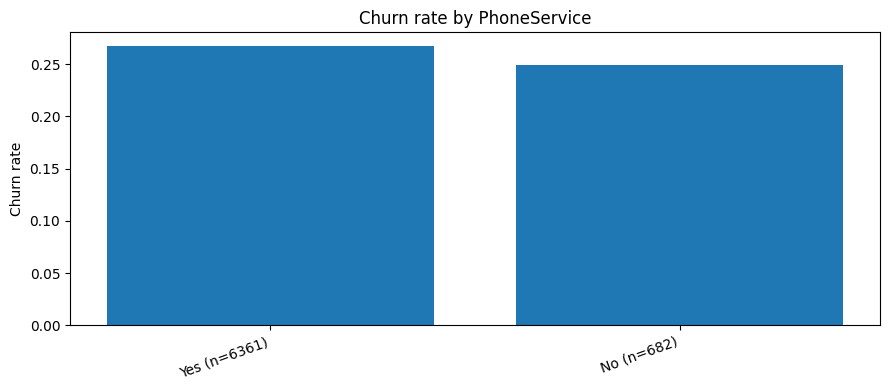


PhoneService
PhoneService     mean  count
         Yes 0.267096   6361
          No 0.249267    682


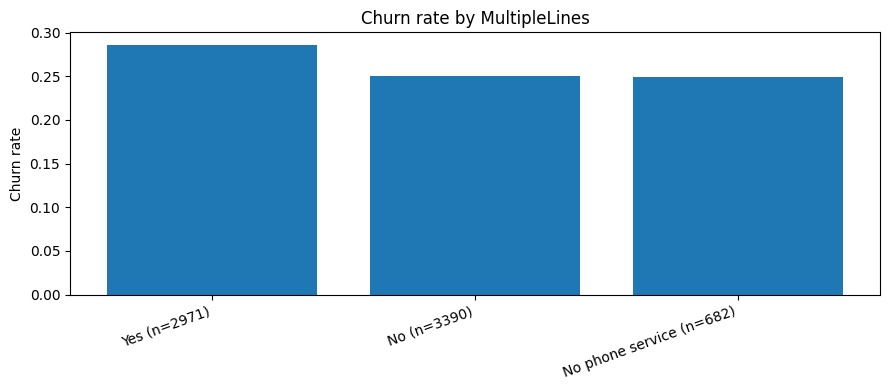


MultipleLines
   MultipleLines     mean  count
             Yes 0.286099   2971
              No 0.250442   3390
No phone service 0.249267    682


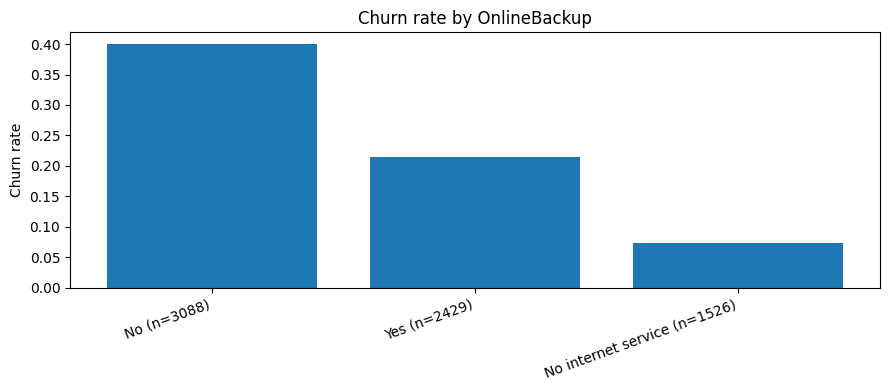


OnlineBackup
       OnlineBackup     mean  count
                 No 0.399288   3088
                Yes 0.215315   2429
No internet service 0.074050   1526


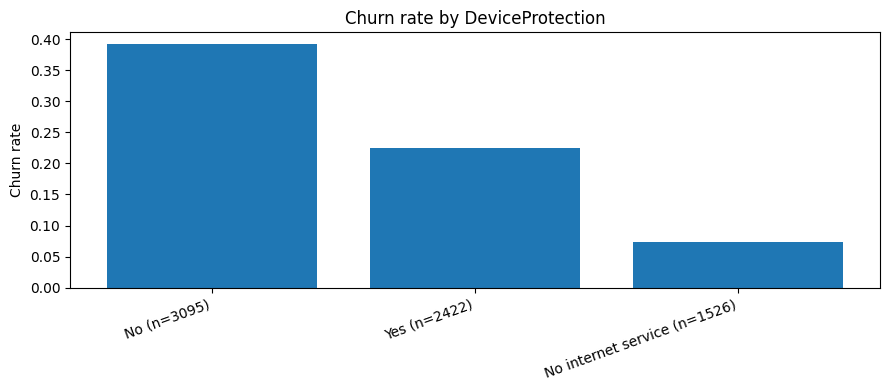


DeviceProtection
   DeviceProtection     mean  count
                 No 0.391276   3095
                Yes 0.225021   2422
No internet service 0.074050   1526


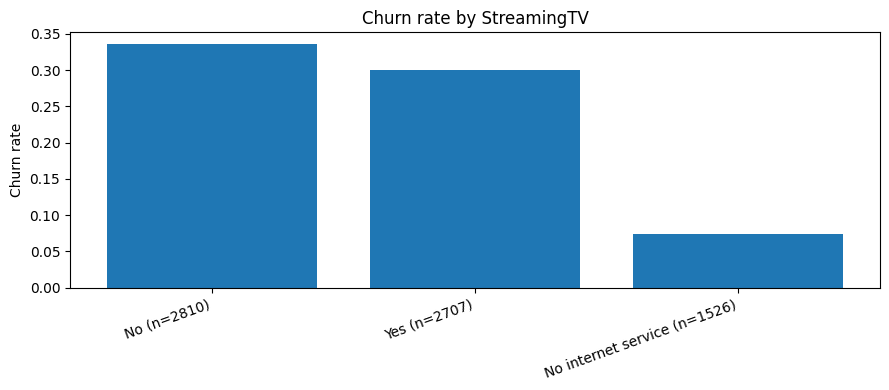


StreamingTV
        StreamingTV     mean  count
                 No 0.335231   2810
                Yes 0.300702   2707
No internet service 0.074050   1526


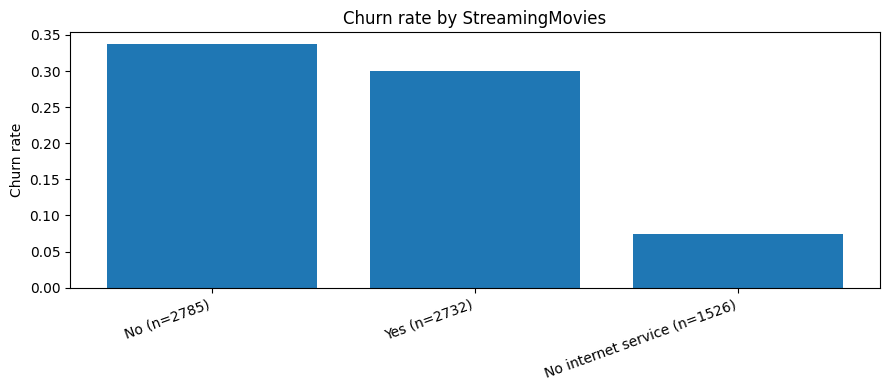


StreamingMovies
    StreamingMovies     mean  count
                 No 0.336804   2785
                Yes 0.299414   2732
No internet service 0.074050   1526


In [39]:
import matplotlib.pyplot as plt

cols = ["PhoneService", "MultipleLines", "OnlineBackup", "DeviceProtection", "StreamingTV", "StreamingMovies"]

for col in cols:
    tmp = df.groupby(col, dropna=False)["churn_flag"].agg(["mean", "count"]).reset_index()
    tmp = tmp.sort_values("mean", ascending=False)

    labels = [f"{str(r[col])} (n={int(r['count'])})" for _, r in tmp.iterrows()]

    plt.figure(figsize=(9, 4))
    plt.bar(labels, tmp["mean"])
    plt.title(f"Churn rate by {col}")
    plt.ylabel("Churn rate")
    plt.xticks(rotation=20, ha="right")
    plt.tight_layout()
    plt.show()

    print("\n" + "=" * 90)
    print(col)
    print(tmp.to_string(index=False))

As pessoas que não tem serviço de backup online costumam churnar mais. <br>
Quem não tem Serviço de Proteção cancela mais <br>
Em geral quando não tem serviço de internet o churn é significativamente menor em todos os cenários. Isso pode indicar que exista uma problema no Serviço de Internet.

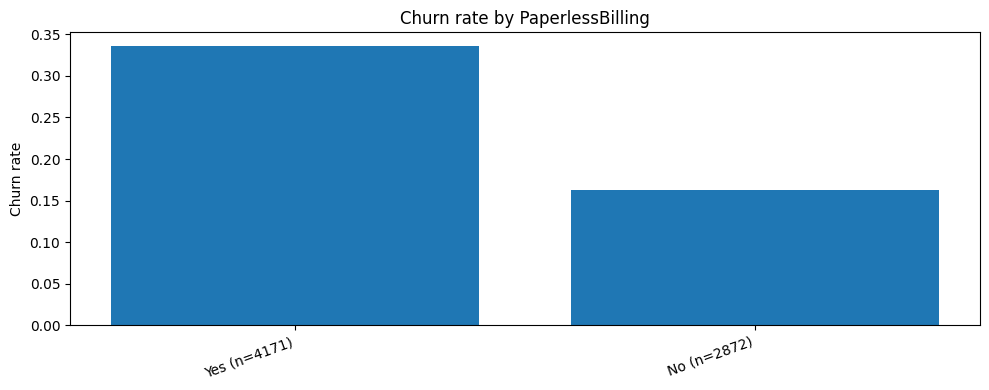


PaperlessBilling
PaperlessBilling     mean  count
             Yes 0.335651   4171
              No 0.163301   2872


In [41]:
import matplotlib.pyplot as plt

cols = ["PaperlessBilling"]

for col in cols:
    tmp = df.groupby(col, dropna=False)["churn_flag"].agg(["mean", "count"]).reset_index()
    tmp = tmp.sort_values("mean", ascending=False)

    labels = [f"{str(r[col])} (n={int(r['count'])})" for _, r in tmp.iterrows()]

    plt.figure(figsize=(10, 4))
    plt.bar(labels, tmp["mean"])
    plt.title(f"Churn rate by {col}")
    plt.ylabel("Churn rate")
    plt.xticks(rotation=20, ha="right")
    plt.tight_layout()
    plt.show()

    print("\n" + "=" * 90)
    print(col)
    print(tmp.to_string(index=False))

Clientes com fatura digital (paperless billing) apresentam maior taxa de churn.

corr:
                SeniorCitizen    tenure  MonthlyCharges  TotalCharges  churn_flag
SeniorCitizen        1.000000  0.016567        0.220173      0.103006    0.150889
tenure               0.016567  1.000000        0.247900      0.826178   -0.352229
MonthlyCharges       0.220173  0.247900        1.000000      0.651174    0.193356
TotalCharges         0.103006  0.826178        0.651174      1.000000   -0.198324
churn_flag           0.150889 -0.352229        0.193356     -0.198324    1.000000


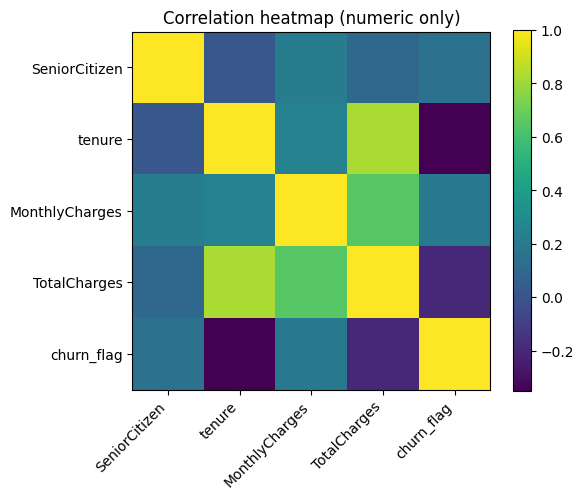

In [42]:
import matplotlib.pyplot as plt

num_cols = ["SeniorCitizen", "tenure", "MonthlyCharges", "TotalCharges", "churn_flag"]
corr = df[num_cols].corr(numeric_only=True)

print("corr:")
print(corr.to_string())

plt.figure(figsize=(6, 5))
plt.imshow(corr.values)
plt.xticks(range(len(num_cols)), num_cols, rotation=45, ha="right")
plt.yticks(range(len(num_cols)), num_cols)
plt.title("Correlation heatmap (numeric only)")
plt.colorbar()
plt.tight_layout()
plt.show()

max_cramers_v_offdiag: 0.9999289848381735


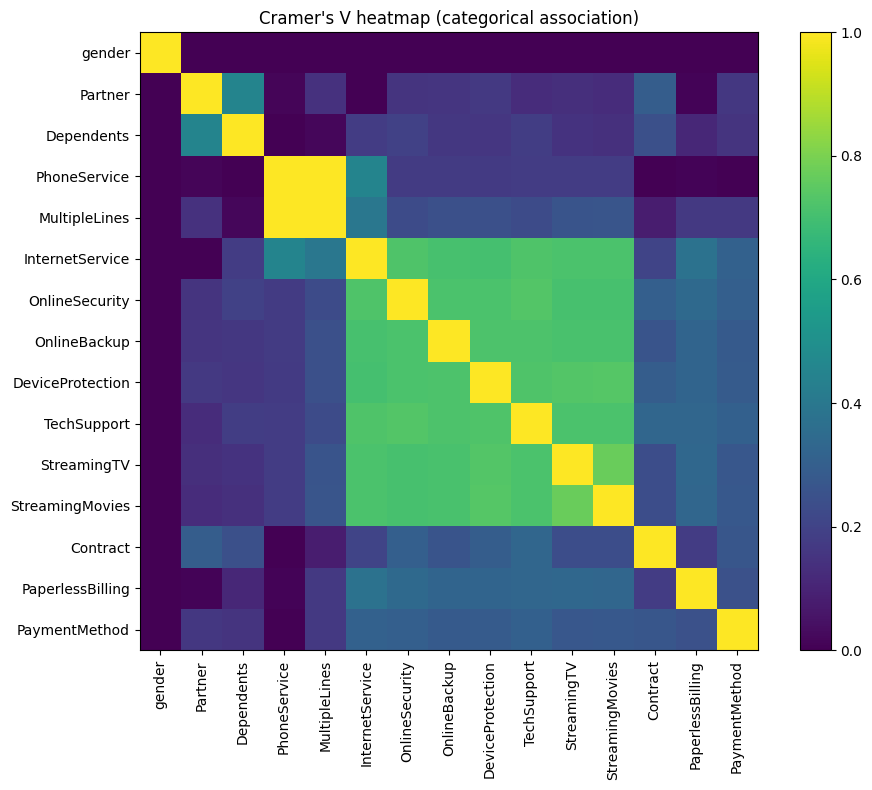

In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

cat_cols = [
    "gender","Partner","Dependents","PhoneService","MultipleLines","InternetService",
    "OnlineSecurity","OnlineBackup","DeviceProtection","TechSupport","StreamingTV","StreamingMovies",
    "Contract","PaperlessBilling","PaymentMethod"
]

def cramers_v(x, y):
    ct = pd.crosstab(x, y)
    n = ct.values.sum()
    if n == 0:
        return np.nan

    row_sum = ct.sum(axis=1).values.reshape(-1, 1)
    col_sum = ct.sum(axis=0).values.reshape(1, -1)
    expected = row_sum @ col_sum / n

    observed = ct.values
    with np.errstate(divide="ignore", invalid="ignore"):
        chi2 = np.nansum((observed - expected) ** 2 / expected)

    r, k = ct.shape
    phi2 = chi2 / n
    phi2corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1)) if n > 1 else 0
    rcorr = r - ((r - 1) ** 2) / (n - 1) if n > 1 else r
    kcorr = k - ((k - 1) ** 2) / (n - 1) if n > 1 else k

    denom = min((kcorr - 1), (rcorr - 1))
    if denom <= 0:
        return 0.0

    return float(np.sqrt(phi2corr / denom))

M = np.zeros((len(cat_cols), len(cat_cols)), dtype=float)

for i in range(len(cat_cols)):
    for j in range(len(cat_cols)):
        if i == j:
            M[i, j] = 1.0
        else:
            M[i, j] = cramers_v(df[cat_cols[i]], df[cat_cols[j]])

print("max_cramers_v_offdiag:", float(np.max(M - np.eye(len(cat_cols)))))

plt.figure(figsize=(10, 8))
plt.imshow(M)
plt.xticks(range(len(cat_cols)), cat_cols, rotation=90)
plt.yticks(range(len(cat_cols)), cat_cols)
plt.title("Cramer's V heatmap (categorical association)")
plt.colorbar()
plt.tight_layout()
plt.show()

In [44]:
import numpy as np
import pandas as pd

cat_cols = [
    "gender","Partner","Dependents","PhoneService","MultipleLines","InternetService",
    "OnlineSecurity","OnlineBackup","DeviceProtection","TechSupport","StreamingTV","StreamingMovies",
    "Contract","PaperlessBilling","PaymentMethod"
]

pairs = []
for i in range(len(cat_cols)):
    for j in range(i + 1, len(cat_cols)):
        v = float(M[i, j])
        pairs.append((v, cat_cols[i], cat_cols[j]))

pairs_sorted = sorted(pairs, key=lambda x: x[0], reverse=True)
print("Top 15 Cramer's V pairs:")
for v, a, b in pairs_sorted[:15]:
    print(f"{v:.6f}  {a}  x  {b}")

Top 15 Cramer's V pairs:
0.999929  PhoneService  x  MultipleLines
0.770967  StreamingTV  x  StreamingMovies
0.735959  DeviceProtection  x  StreamingMovies
0.733572  DeviceProtection  x  StreamingTV
0.732982  OnlineSecurity  x  TechSupport
0.726393  DeviceProtection  x  TechSupport
0.724373  InternetService  x  OnlineSecurity
0.722811  InternetService  x  TechSupport
0.719739  OnlineBackup  x  TechSupport
0.719030  OnlineBackup  x  DeviceProtection
0.718339  OnlineSecurity  x  OnlineBackup
0.717195  OnlineSecurity  x  DeviceProtection
0.717003  InternetService  x  StreamingTV
0.716230  TechSupport  x  StreamingMovies
0.716170  TechSupport  x  StreamingTV


PhoneService  x  MultipleLines. Essas variáveis basicamente contém a mesma informação.

MODEL COMPARISON CELL START
df_shape: (7043, 24)
df_columns: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn', 'churn_flag', 'tenure_band', 'early_tenure']
churn_flag_nulls: 0
churn_rate_overall: 0.2654
churn_value_counts:
churn_flag
0    5174
1    1869
TotalCharges_nulls_before: 0
TotalCharges_nulls_after: 0
missing_expected_feature_cols: []
X_shape: (7043, 19)
y_shape: (7043,)
missing_counts_top:
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract        

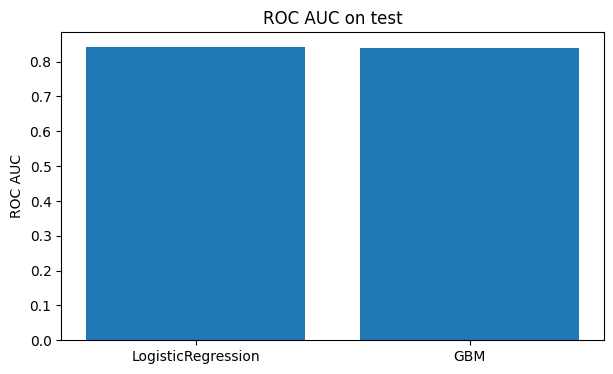

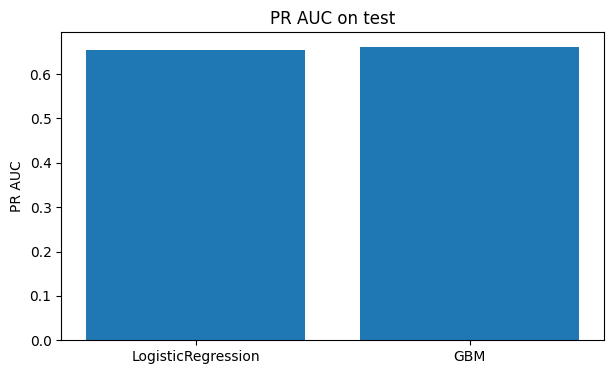

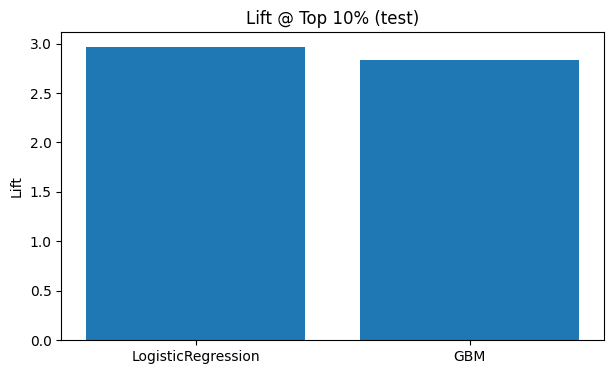

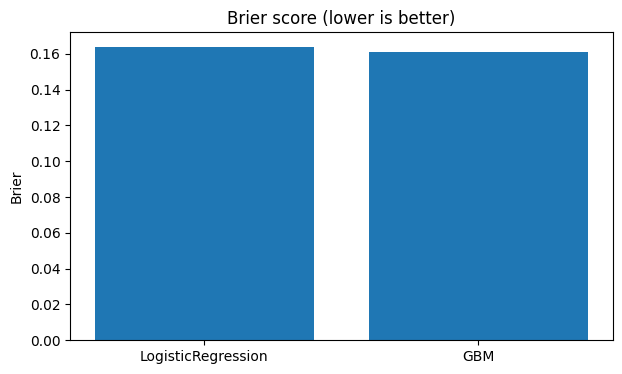

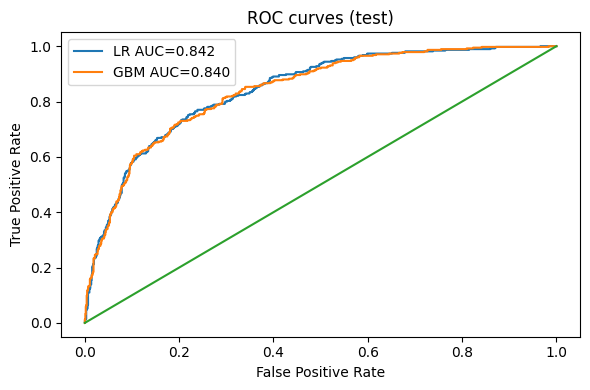

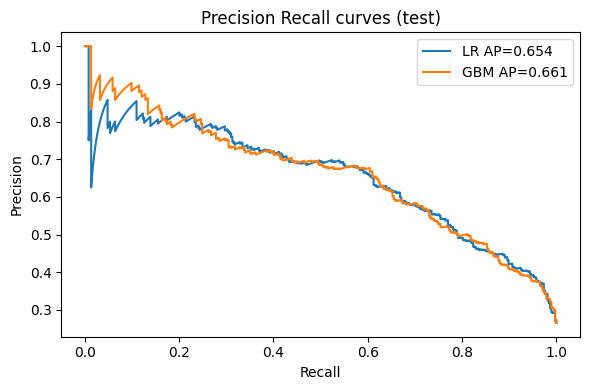


LINEARITY CHECK FOR LOGISTIC (logit vs binned feature means)

feature: tenure
   x_mean  logit_mean   n
 1.248366    0.864193 153
 4.115942    0.871255 138
 9.570470    0.549131 149
15.642857    0.101696 126
24.662338   -0.436954 154
34.903704   -0.909299 135
45.722628   -1.474840 137
55.530201   -1.964594 149
65.390071   -2.489971 141
71.425197   -3.107944 127


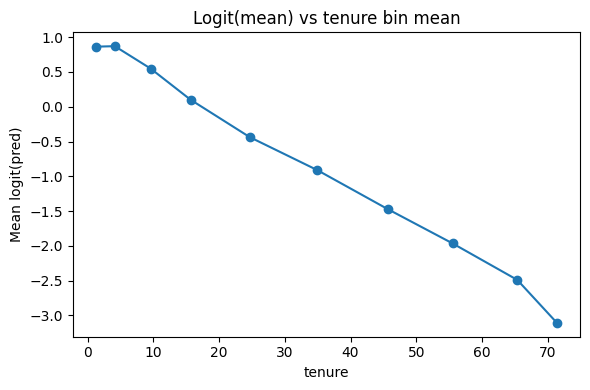


feature: MonthlyCharges
    x_mean  logit_mean   n
 19.646053   -2.235949 152
 21.686154   -2.673502 130
 37.265603   -0.862217 141
 52.514085   -0.553701 142
 64.036170   -1.130956 141
 73.702518    0.116430 139
 80.865603   -0.169428 141
 88.766197   -0.061511 142
 96.924286    0.425136 140
107.422340   -0.564014 141


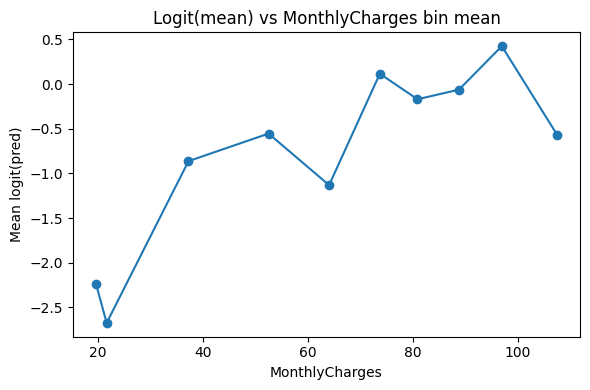


feature: TotalCharges
     x_mean  logit_mean   n
  50.959220    0.522896 141
 182.252837    0.384421 141
 419.854255    0.050296 141
 750.395390   -0.647426 141
1128.189007   -1.383043 141
1649.237857   -1.634698 140
2511.524113   -0.594666 141
3670.194326   -1.329297 141
5152.218085   -1.435800 141
6978.359929   -1.628884 141


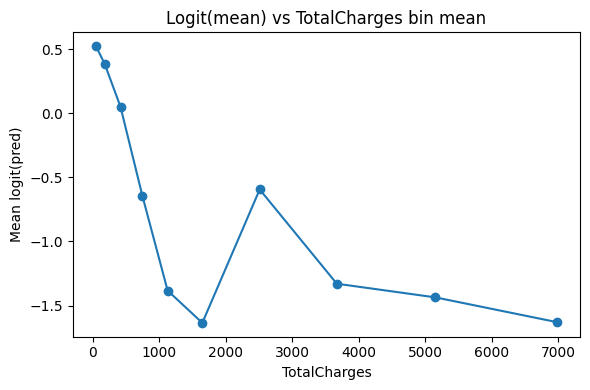


PERMUTATION IMPORTANCE COMPARISON ON TEST (scoring=roc_auc)

Top 20 permutation importance (GBM):
         feature   imp_gbm    imp_lr  rank_gbm  rank_lr
        Contract  0.071849  0.035826       1.0      3.0
          tenure  0.065463  0.186901       2.0      1.0
 InternetService  0.020592  0.013957       3.0      4.0
  MonthlyCharges  0.015140  0.007947       4.0      5.0
   PaymentMethod  0.008228  0.005966       5.0      6.0
  OnlineSecurity  0.007564  0.004852       6.0      8.0
     TechSupport  0.004191  0.005288       7.0      7.0
PaperlessBilling  0.003830  0.002638       8.0      9.0
   MultipleLines  0.003354  0.001225       9.0     10.0
    TotalCharges  0.002966  0.043751      10.0      2.0
 StreamingMovies  0.002195  0.001177      11.0     11.0
   SeniorCitizen  0.002049  0.000975      12.0     13.0
     StreamingTV  0.001817  0.001071      13.0     12.0
    PhoneService  0.000312 -0.000234      14.0     19.0
    OnlineBackup  0.000299  0.000148      15.0     15.0
     

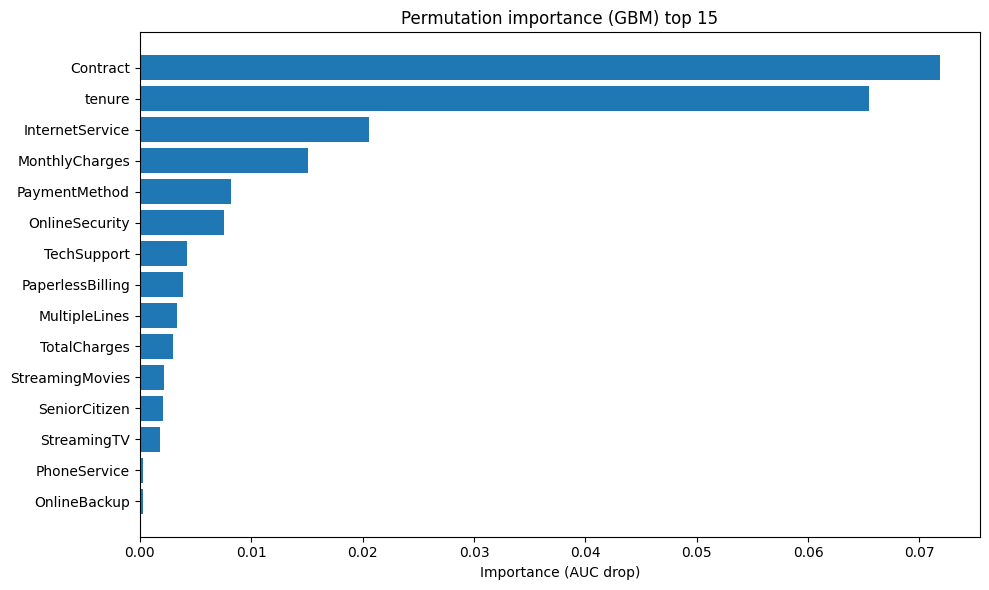

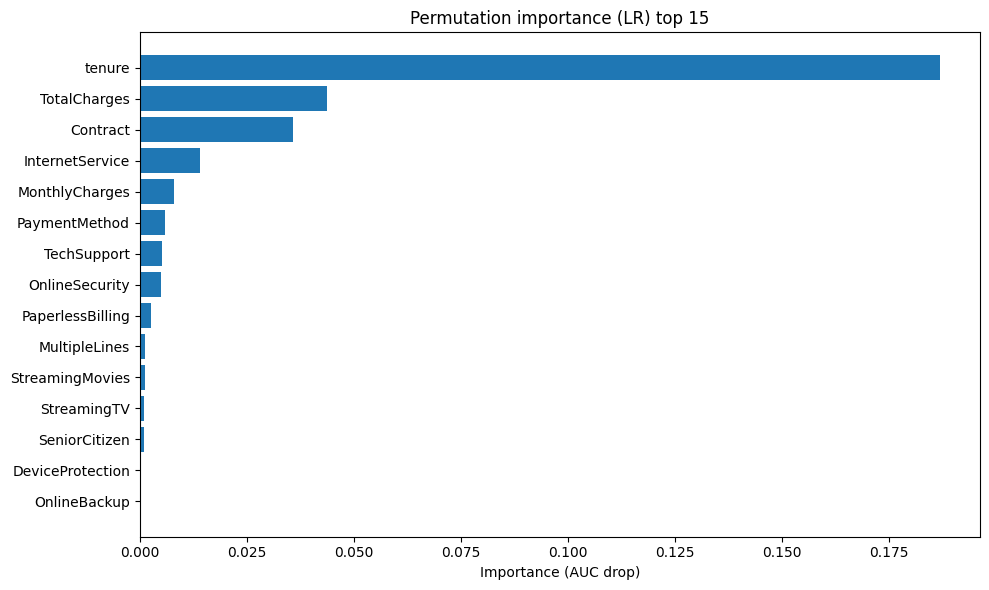

MODEL COMPARISON CELL END


In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve,
    confusion_matrix,
    classification_report,
    brier_score_loss,
)
from sklearn.inspection import permutation_importance

print("MODEL COMPARISON CELL START")
print("df_shape:", df.shape)
print("df_columns:", list(df.columns))

work_df = df.copy()

if "churn_flag" not in work_df.columns:
    work_df["churn_flag"] = work_df["Churn"].astype(str).str.strip().str.lower().map({"yes": 1, "no": 0})

print("churn_flag_nulls:", int(work_df["churn_flag"].isna().sum()))
print("churn_rate_overall:", round(float(work_df["churn_flag"].mean()), 4))
print("churn_value_counts:")
print(work_df["churn_flag"].value_counts(dropna=False).to_string())

tc_nulls = int(work_df["TotalCharges"].isna().sum())
print("TotalCharges_nulls_before:", tc_nulls)
if tc_nulls > 0:
    work_df.loc[work_df["TotalCharges"].isna(), "TotalCharges"] = (
        work_df.loc[work_df["TotalCharges"].isna(), "MonthlyCharges"] * work_df.loc[work_df["TotalCharges"].isna(), "tenure"]
    )
print("TotalCharges_nulls_after:", int(work_df["TotalCharges"].isna().sum()))

base_feature_cols = [
    "gender",
    "SeniorCitizen",
    "Partner",
    "Dependents",
    "tenure",
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaperlessBilling",
    "PaymentMethod",
    "MonthlyCharges",
    "TotalCharges",
]

missing_cols = [c for c in base_feature_cols if c not in work_df.columns]
print("missing_expected_feature_cols:", missing_cols)

X = work_df[base_feature_cols].copy()
y = work_df["churn_flag"].astype(int).copy()

X = X.replace([np.inf, -np.inf], np.nan)

print("X_shape:", X.shape)
print("y_shape:", y.shape)
print("missing_counts_top:")
print(X.isna().sum().sort_values(ascending=False).head(15).to_string())

numeric_features = [c for c in X.columns if pd.api.types.is_numeric_dtype(X[c])]
categorical_features = [c for c in X.columns if c not in numeric_features]

print("numeric_features:", numeric_features)
print("categorical_features_count:", len(categorical_features))

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

print("train_shape:", X_train.shape, "test_shape:", X_test.shape)
print("train_churn_rate:", round(float(y_train.mean()), 4), "test_churn_rate:", round(float(y_test.mean()), 4))

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
    ]
)

try:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", ohe),
    ]
)

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ],
    remainder="drop",
)

pipe_lr = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("model", LogisticRegression(max_iter=4000, solver="liblinear", class_weight="balanced")),
    ]
)

pipe_gbm = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("model", HistGradientBoostingClassifier(random_state=42, max_depth=3, learning_rate=0.04, max_iter=300, class_weight="balanced")),
    ]
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision",
}

print("\nCV metrics (LogisticRegression):")
cv_lr = cross_validate(pipe_lr, X_train, y_train, cv=cv, scoring=scoring, return_train_score=False)
print("roc_auc_scores:", np.round(cv_lr["test_roc_auc"], 4))
print("roc_auc_mean:", round(float(cv_lr["test_roc_auc"].mean()), 4), "std:", round(float(cv_lr["test_roc_auc"].std()), 4))
print("pr_auc_scores:", np.round(cv_lr["test_pr_auc"], 4))
print("pr_auc_mean:", round(float(cv_lr["test_pr_auc"].mean()), 4), "std:", round(float(cv_lr["test_pr_auc"].std()), 4))

print("\nCV metrics (GBM):")
cv_gbm = cross_validate(pipe_gbm, X_train, y_train, cv=cv, scoring=scoring, return_train_score=False)
print("roc_auc_scores:", np.round(cv_gbm["test_roc_auc"], 4))
print("roc_auc_mean:", round(float(cv_gbm["test_roc_auc"].mean()), 4), "std:", round(float(cv_gbm["test_roc_auc"].std()), 4))
print("pr_auc_scores:", np.round(cv_gbm["test_pr_auc"], 4))
print("pr_auc_mean:", round(float(cv_gbm["test_pr_auc"].mean()), 4), "std:", round(float(cv_gbm["test_pr_auc"].std()), 4))

print("\nFITTING BOTH MODELS ON TRAIN")
pipe_lr.fit(X_train, y_train)
pipe_gbm.fit(X_train, y_train)
print("FIT DONE")

proba_lr = pipe_lr.predict_proba(X_test)[:, 1]
proba_gbm = pipe_gbm.predict_proba(X_test)[:, 1]

def ks_stat(y_true, p):
    fpr, tpr, thr = roc_curve(y_true, p)
    ks = float(np.max(tpr - fpr))
    return ks

def lift_metrics(y_true, p, frac):
    n = len(y_true)
    k = int(np.ceil(frac * n))
    idx = np.argsort(-p)
    top = y_true.iloc[idx[:k]]
    base_rate = float(y_true.mean())
    top_rate = float(top.mean())
    lift = top_rate / base_rate if base_rate > 0 else np.nan
    recall_at_k = float(top.sum()) / float(y_true.sum()) if float(y_true.sum()) > 0 else np.nan
    precision_at_k = float(top.mean())
    return {
        "k": k,
        "top_rate": top_rate,
        "base_rate": base_rate,
        "lift": lift,
        "recall_at_k": recall_at_k,
        "precision_at_k": precision_at_k,
    }

def eval_model(name, p):
    roc_auc = roc_auc_score(y_test, p)
    pr_auc = average_precision_score(y_test, p)
    ks = ks_stat(y_test, p)
    brier = brier_score_loss(y_test, p)
    m10 = lift_metrics(y_test, p, 0.10)
    m20 = lift_metrics(y_test, p, 0.20)
    return {
        "model": name,
        "roc_auc": float(roc_auc),
        "pr_auc": float(pr_auc),
        "ks": float(ks),
        "brier": float(brier),
        "lift_10": float(m10["lift"]),
        "recall_10": float(m10["recall_at_k"]),
        "precision_10": float(m10["precision_at_k"]),
        "lift_20": float(m20["lift"]),
        "recall_20": float(m20["recall_at_k"]),
        "precision_20": float(m20["precision_at_k"]),
    }

res_lr = eval_model("LogisticRegression", proba_lr)
res_gbm = eval_model("GBM", proba_gbm)

summary = pd.DataFrame([res_lr, res_gbm])
print("\nTEST SUMMARY (ranking + calibration metrics):")
print(summary.to_string(index=False))

plt.figure(figsize=(7, 4))
plt.bar(summary["model"], summary["roc_auc"])
plt.title("ROC AUC on test")
plt.ylabel("ROC AUC")
plt.show()

plt.figure(figsize=(7, 4))
plt.bar(summary["model"], summary["pr_auc"])
plt.title("PR AUC on test")
plt.ylabel("PR AUC")
plt.show()

plt.figure(figsize=(7, 4))
plt.bar(summary["model"], summary["lift_10"])
plt.title("Lift @ Top 10% (test)")
plt.ylabel("Lift")
plt.show()

plt.figure(figsize=(7, 4))
plt.bar(summary["model"], summary["brier"])
plt.title("Brier score (lower is better)")
plt.ylabel("Brier")
plt.show()

fpr_lr, tpr_lr, _ = roc_curve(y_test, proba_lr)
fpr_gbm, tpr_gbm, _ = roc_curve(y_test, proba_gbm)

plt.figure(figsize=(6, 4))
plt.plot(fpr_lr, tpr_lr, label=f"LR AUC={res_lr['roc_auc']:.3f}")
plt.plot(fpr_gbm, tpr_gbm, label=f"GBM AUC={res_gbm['roc_auc']:.3f}")
plt.plot([0, 1], [0, 1])
plt.title("ROC curves (test)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()

prec_lr, rec_lr, _ = precision_recall_curve(y_test, proba_lr)
prec_gbm, rec_gbm, _ = precision_recall_curve(y_test, proba_gbm)

plt.figure(figsize=(6, 4))
plt.plot(rec_lr, prec_lr, label=f"LR AP={res_lr['pr_auc']:.3f}")
plt.plot(rec_gbm, prec_gbm, label=f"GBM AP={res_gbm['pr_auc']:.3f}")
plt.title("Precision Recall curves (test)")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.tight_layout()
plt.show()

print("\nLINEARITY CHECK FOR LOGISTIC (logit vs binned feature means)")
eps = 1e-6
logit_lr = np.log(np.clip(proba_lr, eps, 1 - eps) / np.clip(1 - proba_lr, eps, 1 - eps))
tmp_lin = X_test.copy()
tmp_lin["logit_lr"] = logit_lr

def plot_logit_vs_feature_bins(feature, q=10):
    s = tmp_lin[feature].astype(float)
    bins = pd.qcut(s, q, duplicates="drop")
    g = tmp_lin.groupby(bins, observed=False).agg(
        x_mean=(feature, "mean"),
        logit_mean=("logit_lr", "mean"),
        n=("logit_lr", "size"),
    ).reset_index(drop=True)

    print("\nfeature:", feature)
    print(g.to_string(index=False))

    plt.figure(figsize=(6, 4))
    plt.plot(g["x_mean"], g["logit_mean"], marker="o")
    plt.title(f"Logit(mean) vs {feature} bin mean")
    plt.xlabel(feature)
    plt.ylabel("Mean logit(pred)")
    plt.tight_layout()
    plt.show()

for feat in ["tenure", "MonthlyCharges", "TotalCharges"]:
    plot_logit_vs_feature_bins(feat, q=10)

print("\nPERMUTATION IMPORTANCE COMPARISON ON TEST (scoring=roc_auc)")
perm_lr = permutation_importance(pipe_lr, X_test, y_test, scoring="roc_auc", n_repeats=5, random_state=42)
perm_gbm = permutation_importance(pipe_gbm, X_test, y_test, scoring="roc_auc", n_repeats=5, random_state=42)

imp_lr = pd.DataFrame({"feature": X_test.columns, "imp_lr": perm_lr.importances_mean}).sort_values("imp_lr", ascending=False)
imp_gbm = pd.DataFrame({"feature": X_test.columns, "imp_gbm": perm_gbm.importances_mean}).sort_values("imp_gbm", ascending=False)

imp_merge = imp_lr.merge(imp_gbm, on="feature", how="outer")
imp_merge = imp_merge.fillna(0.0)
imp_merge["rank_lr"] = imp_merge["imp_lr"].rank(ascending=False, method="average")
imp_merge["rank_gbm"] = imp_merge["imp_gbm"].rank(ascending=False, method="average")
imp_merge = imp_merge.sort_values("imp_gbm", ascending=False)

print("\nTop 20 permutation importance (GBM):")
print(imp_merge[["feature", "imp_gbm", "imp_lr", "rank_gbm", "rank_lr"]].head(20).to_string(index=False))

plt.figure(figsize=(10, 6))
top = imp_merge.head(15).iloc[::-1]
plt.barh(top["feature"], top["imp_gbm"])
plt.title("Permutation importance (GBM) top 15")
plt.xlabel("Importance (AUC drop)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
top = imp_merge.sort_values("imp_lr", ascending=False).head(15).iloc[::-1]
plt.barh(top["feature"], top["imp_lr"])
plt.title("Permutation importance (LR) top 15")
plt.xlabel("Importance (AUC drop)")
plt.tight_layout()
plt.show()

print("MODEL COMPARISON CELL END")

GBM MODEL CELL START
df_shape: (7043, 23)
churn_flag_nulls: 0
churn_rate_overall: 0.2654
churn_value_counts:
churn_flag
0    5174
1    1869
TotalCharges_nulls_before: 0
TotalCharges_nulls_after: 0
missing_expected_feature_cols: []
X_shape: (7043, 19)
y_shape: (7043,)
missing_counts_top:
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
numeric_features: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
categorical_features_count: 15
categorical_features: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
train_sha

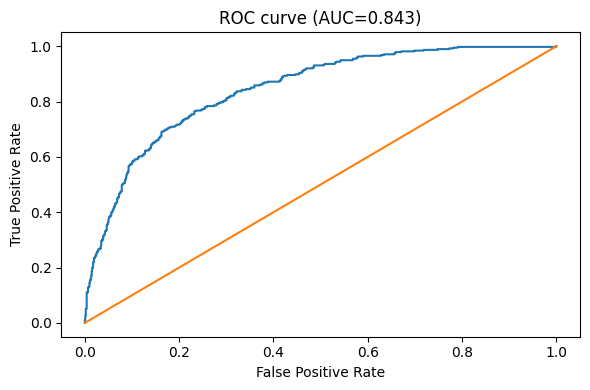

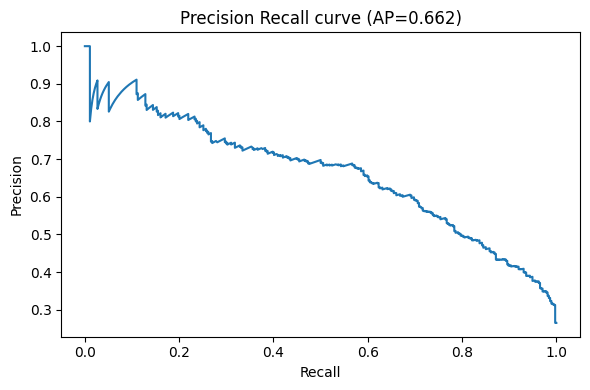


LIFT TABLE (top decile first):
 decile  churn_rate   n    p_min    p_max
      9    0.744681 141 0.836705 0.970780
      8    0.624113 141 0.729967 0.835805
      7    0.439716 141 0.614944 0.729854
      6    0.269504 141 0.493567 0.614354
      5    0.200000 140 0.355231 0.492922
      4    0.170213 141 0.239565 0.353753
      3    0.113475 141 0.138742 0.237747
      2    0.056738 141 0.070488 0.138129
      1    0.028369 141 0.035840 0.069647
      0    0.007092 141 0.009783 0.035739


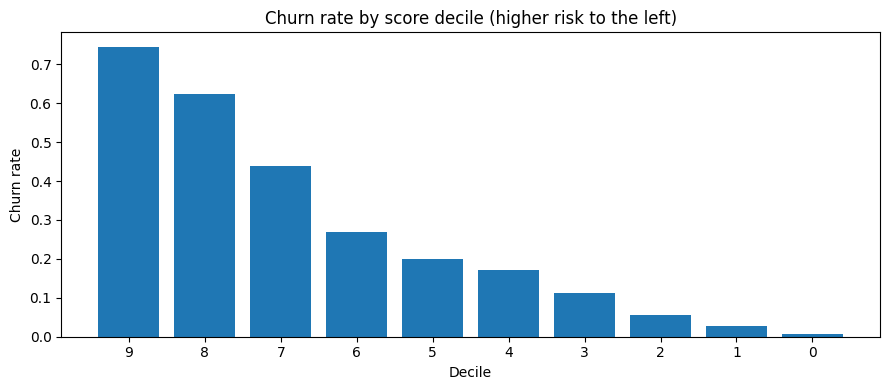


PERMUTATION IMPORTANCE (original features, scoring=roc_auc)

Top 25 features by permutation importance:
         feature  importance_mean  importance_std
        Contract         0.071061        0.008897
          tenure         0.047681        0.008159
 InternetService         0.019034        0.004093
  MonthlyCharges         0.018530        0.003515
   PaymentMethod         0.007060        0.001558
  OnlineSecurity         0.006445        0.002285
     TechSupport         0.003353        0.001799
PaperlessBilling         0.003219        0.001640
   MultipleLines         0.002985        0.001112
     StreamingTV         0.001710        0.000605
 StreamingMovies         0.001385        0.000479
   SeniorCitizen         0.001352        0.000792
    TotalCharges         0.000592        0.001840
      Dependents         0.000234        0.000111
          gender         0.000172        0.000280
         Partner         0.000033        0.000090
    PhoneService         0.000019        0.00

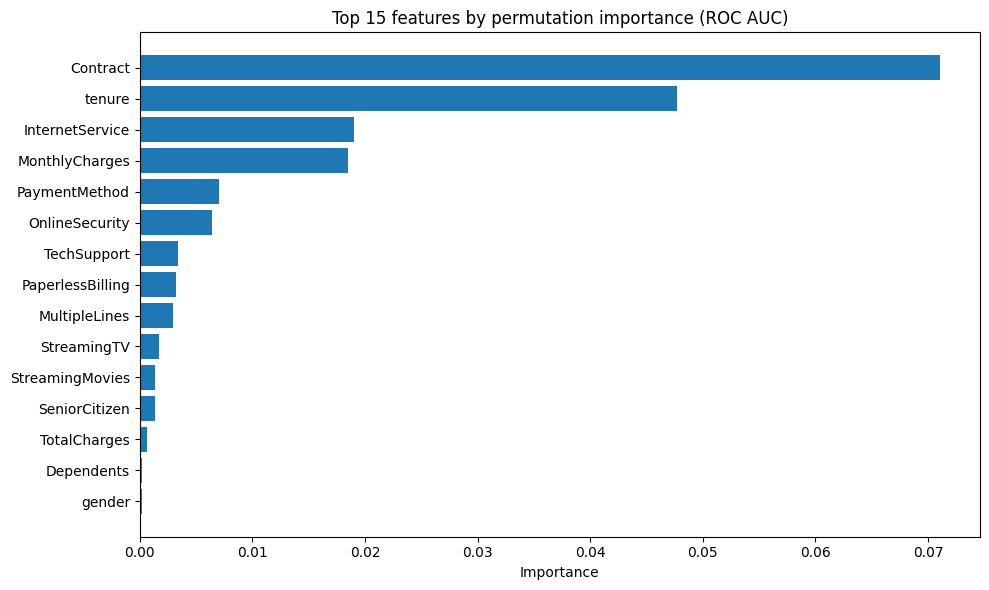

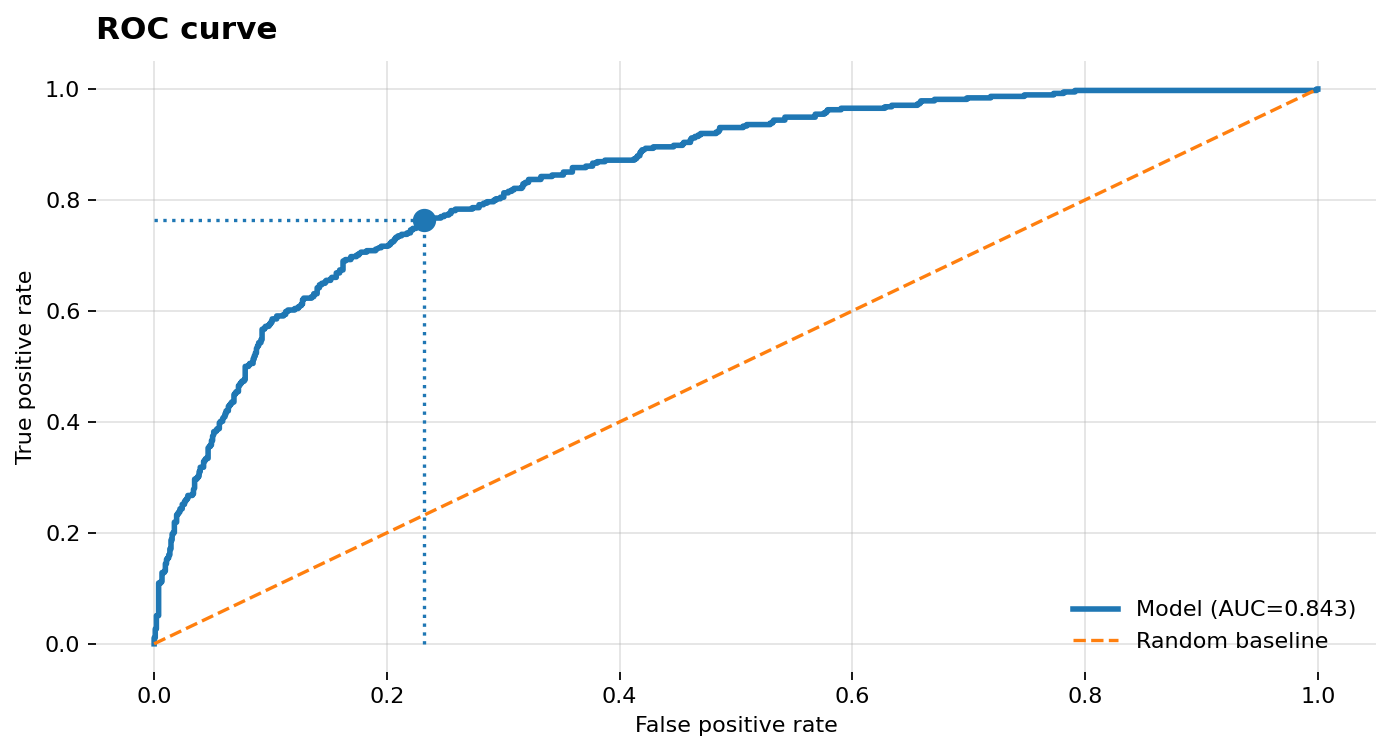

[PLOT] ROC summary
roc_auc: 0.8429
ks: 0.5328
ks_point_fpr: 0.2319 ks_point_tpr: 0.7647

GBM MODEL CELL END


In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve,
    confusion_matrix,
    classification_report,
)
from sklearn.inspection import permutation_importance

print("GBM MODEL CELL START")
print("df_shape:", df.shape)

work_df = df.copy()

if "churn_flag" not in work_df.columns:
    work_df["churn_flag"] = work_df["Churn"].astype(str).str.strip().str.lower().map({"yes": 1, "no": 0})

print("churn_flag_nulls:", int(work_df["churn_flag"].isna().sum()))
print("churn_rate_overall:", round(float(work_df["churn_flag"].mean()), 4))
print("churn_value_counts:")
print(work_df["churn_flag"].value_counts(dropna=False).to_string())

tc_nulls = int(work_df["TotalCharges"].isna().sum())
print("TotalCharges_nulls_before:", tc_nulls)
if tc_nulls > 0:
    work_df.loc[work_df["TotalCharges"].isna(), "TotalCharges"] = (
        work_df.loc[work_df["TotalCharges"].isna(), "MonthlyCharges"] * work_df.loc[work_df["TotalCharges"].isna(), "tenure"]
    )
print("TotalCharges_nulls_after:", int(work_df["TotalCharges"].isna().sum()))

base_feature_cols = [
    "gender",
    "SeniorCitizen",
    "Partner",
    "Dependents",
    "tenure",
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaperlessBilling",
    "PaymentMethod",
    "MonthlyCharges",
    "TotalCharges",
]

missing_cols = [c for c in base_feature_cols if c not in work_df.columns]
print("missing_expected_feature_cols:", missing_cols)

X = work_df[base_feature_cols].copy()
y = work_df["churn_flag"].astype(int).copy()

X = X.replace([np.inf, -np.inf], np.nan)

print("X_shape:", X.shape)
print("y_shape:", y.shape)
print("missing_counts_top:")
print(X.isna().sum().sort_values(ascending=False).head(15).to_string())

numeric_features = [c for c in X.columns if pd.api.types.is_numeric_dtype(X[c])]
categorical_features = [c for c in X.columns if c not in numeric_features]

print("numeric_features:", numeric_features)
print("categorical_features_count:", len(categorical_features))
print("categorical_features:", categorical_features)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

print("train_shape:", X_train.shape, "test_shape:", X_test.shape)
print("train_churn_rate:", round(float(y_train.mean()), 4), "test_churn_rate:", round(float(y_test.mean()), 4))

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
    ]
)

try:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", ohe),
    ]
)

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ],
    remainder="drop",
)

gbm = HistGradientBoostingClassifier(
    random_state=42,
    class_weight="balanced",
)

pipe_gbm = Pipeline(steps=[("preprocess", preprocess), ("model", gbm)])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("\nCV ROC AUC (baseline GBM):")
cv_scores = cross_val_score(pipe_gbm, X_train, y_train, cv=cv, scoring="roc_auc")
print("scores:", np.round(cv_scores, 4))
print("mean:", round(float(cv_scores.mean()), 4), "std:", round(float(cv_scores.std()), 4))

param_dist = {
    "model__learning_rate": [0.02, 0.04, 0.06, 0.08, 0.12],
    "model__max_depth": [2, 3, 4, 5, None],
    "model__max_leaf_nodes": [15, 31, 63, 127],
    "model__min_samples_leaf": [10, 20, 40, 80],
    "model__l2_regularization": [0.0, 0.1, 0.5, 1.0, 2.0],
    "model__max_iter": [200, 400, 700, 1000],
}

print("\nRandomizedSearchCV START")
search = RandomizedSearchCV(
    estimator=pipe_gbm,
    param_distributions=param_dist,
    n_iter=20,
    scoring="roc_auc",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=0,
)

search.fit(X_train, y_train)

print("RandomizedSearchCV DONE")
print("best_cv_roc_auc:", round(float(search.best_score_), 4))
print("best_params:")
print(search.best_params_)

best_pipe = search.best_estimator_
print("\nFITTING BEST PIPE ON TRAIN")
best_pipe.fit(X_train, y_train)
print("FIT DONE")

proba_test = best_pipe.predict_proba(X_test)[:, 1]
pred_05 = (proba_test >= 0.5).astype(int)

roc_auc = roc_auc_score(y_test, proba_test)
pr_auc = average_precision_score(y_test, proba_test)

fpr, tpr, thr = roc_curve(y_test, proba_test)
ks = float(np.max(tpr - fpr))
ks_thr = float(thr[int(np.argmax(tpr - fpr))])

print("\nTEST METRICS")
print("roc_auc:", round(float(roc_auc), 4))
print("pr_auc:", round(float(pr_auc), 4))
print("ks:", round(float(ks), 4))
print("ks_threshold:", round(float(ks_thr), 4))

cm05 = confusion_matrix(y_test, pred_05)
print("\nconfusion_matrix_threshold_0.5:")
print(cm05)

print("\nclassification_report_threshold_0.5:")
print(classification_report(y_test, pred_05, digits=4, zero_division=0))

prec_curve, rec_curve, thr_pr = precision_recall_curve(y_test, proba_test)
f1_curve = (2 * prec_curve * rec_curve) / np.maximum(prec_curve + rec_curve, 1e-12)
best_f1_idx = int(np.nanargmax(f1_curve))
best_f1 = float(f1_curve[best_f1_idx])
best_thr_f1 = float(thr_pr[best_f1_idx - 1]) if best_f1_idx > 0 and best_f1_idx - 1 < len(thr_pr) else 0.5

pred_best_f1 = (proba_test >= best_thr_f1).astype(int)
cm_best_f1 = confusion_matrix(y_test, pred_best_f1)

print("\nTHRESHOLD BY MAX F1 (diagnostic)")
print("best_threshold_f1:", round(float(best_thr_f1), 4))
print("best_f1:", round(float(best_f1), 4))
print("confusion_matrix_best_f1:")
print(cm_best_f1)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1])
plt.title(f"ROC curve (AUC={roc_auc:.3f})")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(rec_curve, prec_curve)
plt.title(f"Precision Recall curve (AP={pr_auc:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.tight_layout()
plt.show()

score_df = pd.DataFrame({"y": y_test.values, "p": proba_test})
score_df["decile"] = pd.qcut(score_df["p"], 10, labels=False, duplicates="drop")
lift = score_df.groupby("decile", observed=False).agg(
    churn_rate=("y", "mean"),
    n=("y", "size"),
    p_min=("p", "min"),
    p_max=("p", "max"),
).reset_index()
lift = lift.sort_values("decile", ascending=False)

print("\nLIFT TABLE (top decile first):")
print(lift.to_string(index=False))

plt.figure(figsize=(9, 4))
plt.bar(lift["decile"].astype(str), lift["churn_rate"])
plt.title("Churn rate by score decile (higher risk to the left)")
plt.xlabel("Decile")
plt.ylabel("Churn rate")
plt.tight_layout()
plt.show()

print("\nPERMUTATION IMPORTANCE (original features, scoring=roc_auc)")
perm = permutation_importance(
    best_pipe,
    X_test,
    y_test,
    scoring="roc_auc",
    n_repeats=7,
    random_state=42,
)

imp = pd.DataFrame(
    {
        "feature": X_test.columns,
        "importance_mean": perm.importances_mean,
        "importance_std": perm.importances_std,
    }
).sort_values("importance_mean", ascending=False)

print("\nTop 25 features by permutation importance:")
print(imp.head(25).to_string(index=False))

plt.figure(figsize=(10, 6))
topk = imp.head(15).iloc[::-1]
plt.barh(topk["feature"], topk["importance_mean"])
plt.title("Top 15 features by permutation importance (ROC AUC)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8.8, 4.8), dpi=160)
plt.plot(fpr, tpr, linewidth=2.5, label=f"Model (AUC={roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1.5, label="Random baseline")

ks_idx = int(np.argmax(tpr - fpr))
ks_fpr = float(fpr[ks_idx])
ks_tpr = float(tpr[ks_idx])

plt.scatter([ks_fpr], [ks_tpr], s=90)
plt.vlines(ks_fpr, 0, ks_tpr, linestyles=":", linewidth=1.5)
plt.hlines(ks_tpr, 0, ks_fpr, linestyles=":", linewidth=1.5)

plt.title("ROC curve", loc="left", fontsize=14, fontweight="bold", pad=10)
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")

ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(False)
ax.grid(axis="both", linestyle="-", linewidth=0.8, alpha=0.35)
ax.set_axisbelow(True)

plt.legend(frameon=False, loc="lower right")
plt.tight_layout()
plt.show()

print("[PLOT] ROC summary")
print("roc_auc:", round(float(roc_auc), 4))
print("ks:", round(float(ks), 4))
print("ks_point_fpr:", round(float(ks_fpr), 4), "ks_point_tpr:", round(float(ks_tpr), 4))

print("\nGBM MODEL CELL END")

ks: 0.532822
ks_threshold: 0.525476

confusion_matrix_at_ks_threshold:
[[795 240]
 [ 88 286]]

metrics_at_ks_threshold (class 0 and 1):
 threshold       ks  precision_0  recall_0     f1_0  precision_1  recall_1     f1_1    tpr_1      fpr  accuracy  balanced_accuracy  tp  fp  tn  fn
  0.525476 0.532822      0.90034  0.768116 0.828989     0.543726  0.764706 0.635556 0.764706 0.231884  0.767211           0.766411 286 240 795  88


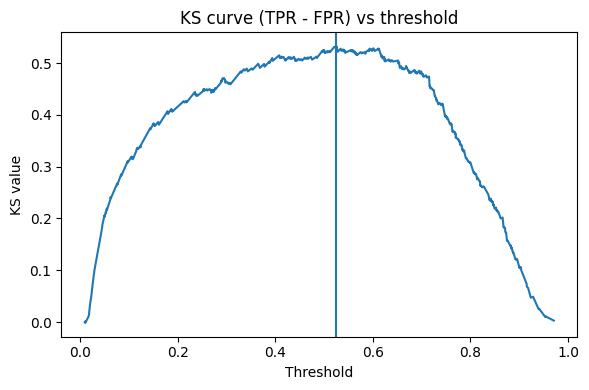

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, confusion_matrix

fpr, tpr, thr = roc_curve(y_test, proba_test)
ks_values = tpr - fpr
idx = int(np.argmax(ks_values))

ks = float(ks_values[idx])
ks_thr = float(thr[idx])

print("ks:", round(ks, 6))
print("ks_threshold:", round(ks_thr, 6))

pred_ks = (proba_test >= ks_thr).astype(int)
tn, fp, fn, tp = confusion_matrix(y_test, pred_ks).ravel()

recall_1 = tp / (tp + fn) if (tp + fn) else 0.0
precision_1 = tp / (tp + fp) if (tp + fp) else 0.0
f1_1 = (2 * precision_1 * recall_1) / (precision_1 + recall_1) if (precision_1 + recall_1) else 0.0

recall_0 = tn / (tn + fp) if (tn + fp) else 0.0
precision_0 = tn / (tn + fn) if (tn + fn) else 0.0
f1_0 = (2 * precision_0 * recall_0) / (precision_0 + recall_0) if (precision_0 + recall_0) else 0.0

accuracy = (tp + tn) / (tp + tn + fp + fn) if (tp + tn + fp + fn) else 0.0
balanced_accuracy = 0.5 * (recall_1 + recall_0)

fpr_ks = fp / (fp + tn) if (fp + tn) else 0.0
tpr_ks = recall_1

print("\nconfusion_matrix_at_ks_threshold:")
print(np.array([[tn, fp], [fn, tp]]))

metrics = pd.DataFrame(
    [{
        "threshold": ks_thr,
        "ks": ks,
        "precision_0": precision_0,
        "recall_0": recall_0,
        "f1_0": f1_0,
        "precision_1": precision_1,
        "recall_1": recall_1,
        "f1_1": f1_1,
        "tpr_1": tpr_ks,
        "fpr": fpr_ks,
        "accuracy": accuracy,
        "balanced_accuracy": balanced_accuracy,
        "tp": tp,
        "fp": fp,
        "tn": tn,
        "fn": fn,
    }]
)

print("\nmetrics_at_ks_threshold (class 0 and 1):")
print(metrics.to_string(index=False))

plt.figure(figsize=(6, 4))
plt.plot(thr, ks_values)
plt.title("KS curve (TPR - FPR) vs threshold")
plt.xlabel("Threshold")
plt.ylabel("KS value")
plt.axvline(ks_thr)
plt.tight_layout()
plt.show()


SHAP START
shap_version: 0.49.1
X_test_trans_shape: (1409, 45)
feature_names_count: 45
shap_vals_pos_shape: (1409, 45)


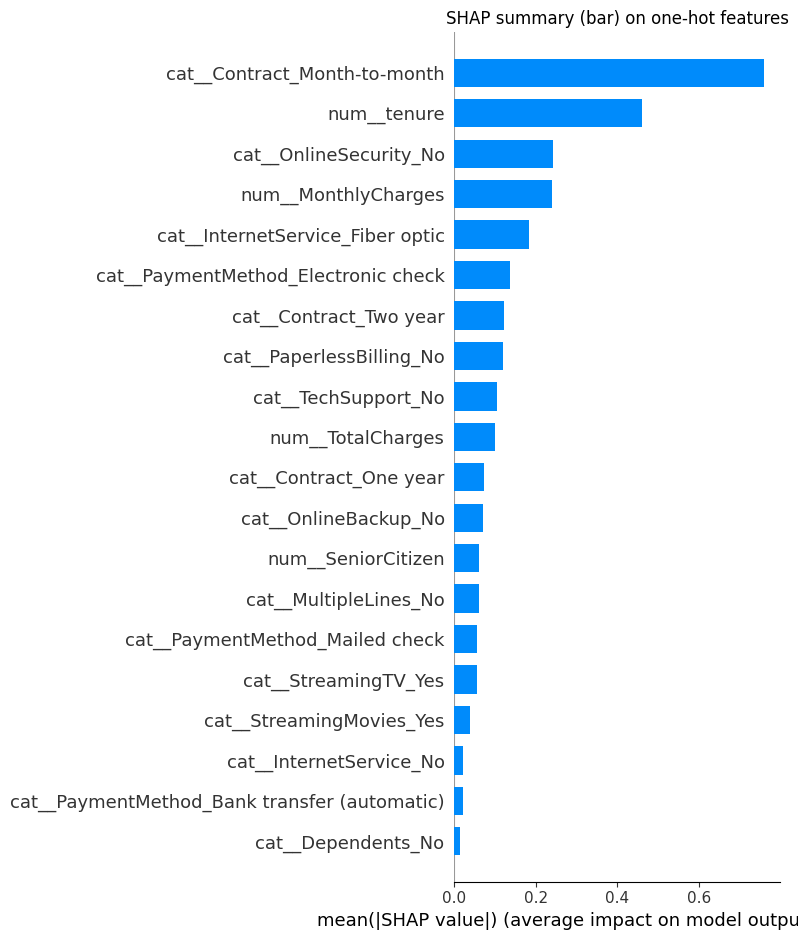

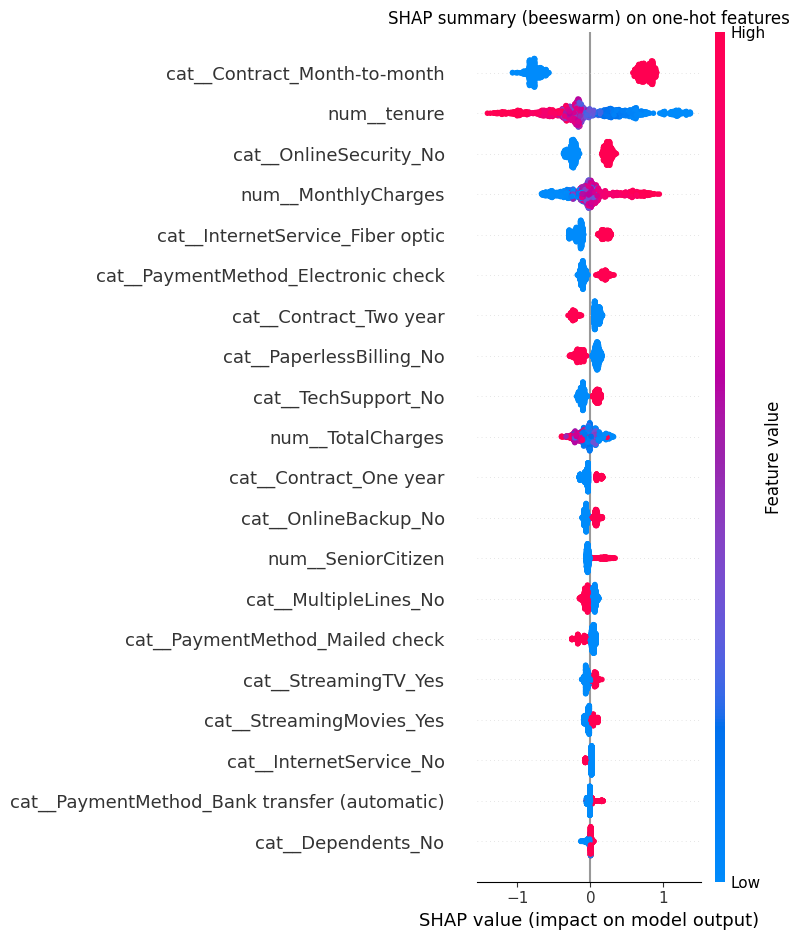


Top 20 base features by aggregated mean(|SHAP|):
    base_feature  mean_abs_shap
        Contract       0.956426
          tenure       0.461331
  OnlineSecurity       0.243079
  MonthlyCharges       0.240443
   PaymentMethod       0.219337
 InternetService       0.214471
PaperlessBilling       0.127030
     TechSupport       0.108448
    TotalCharges       0.100808
    OnlineBackup       0.073361
     StreamingTV       0.063588
   MultipleLines       0.060717
   SeniorCitizen       0.060013
 StreamingMovies       0.042501
      Dependents       0.014926
          gender       0.011922
    PhoneService       0.007857
         Partner       0.003806
DeviceProtection       0.002838


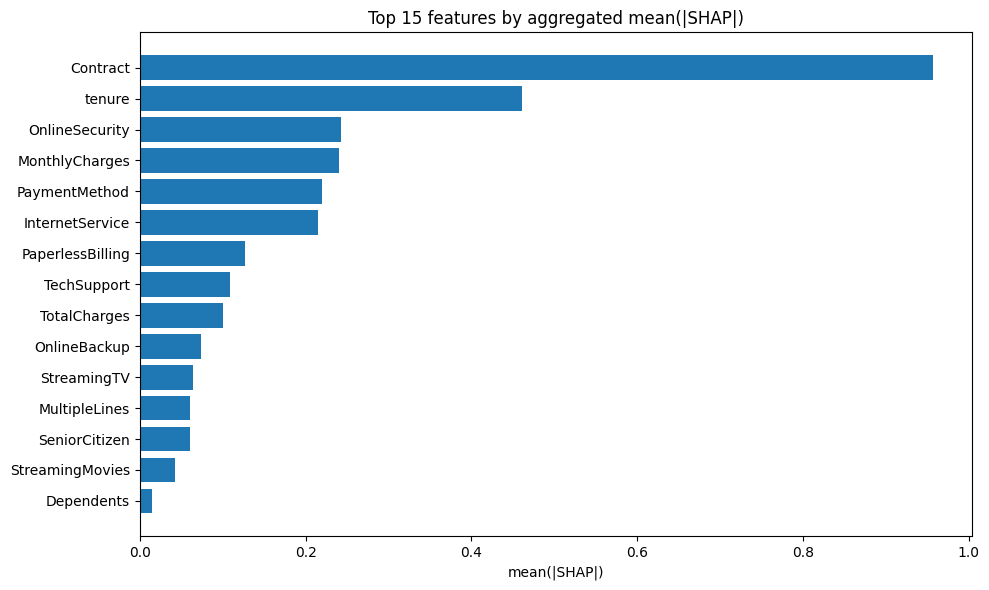

SHAP END


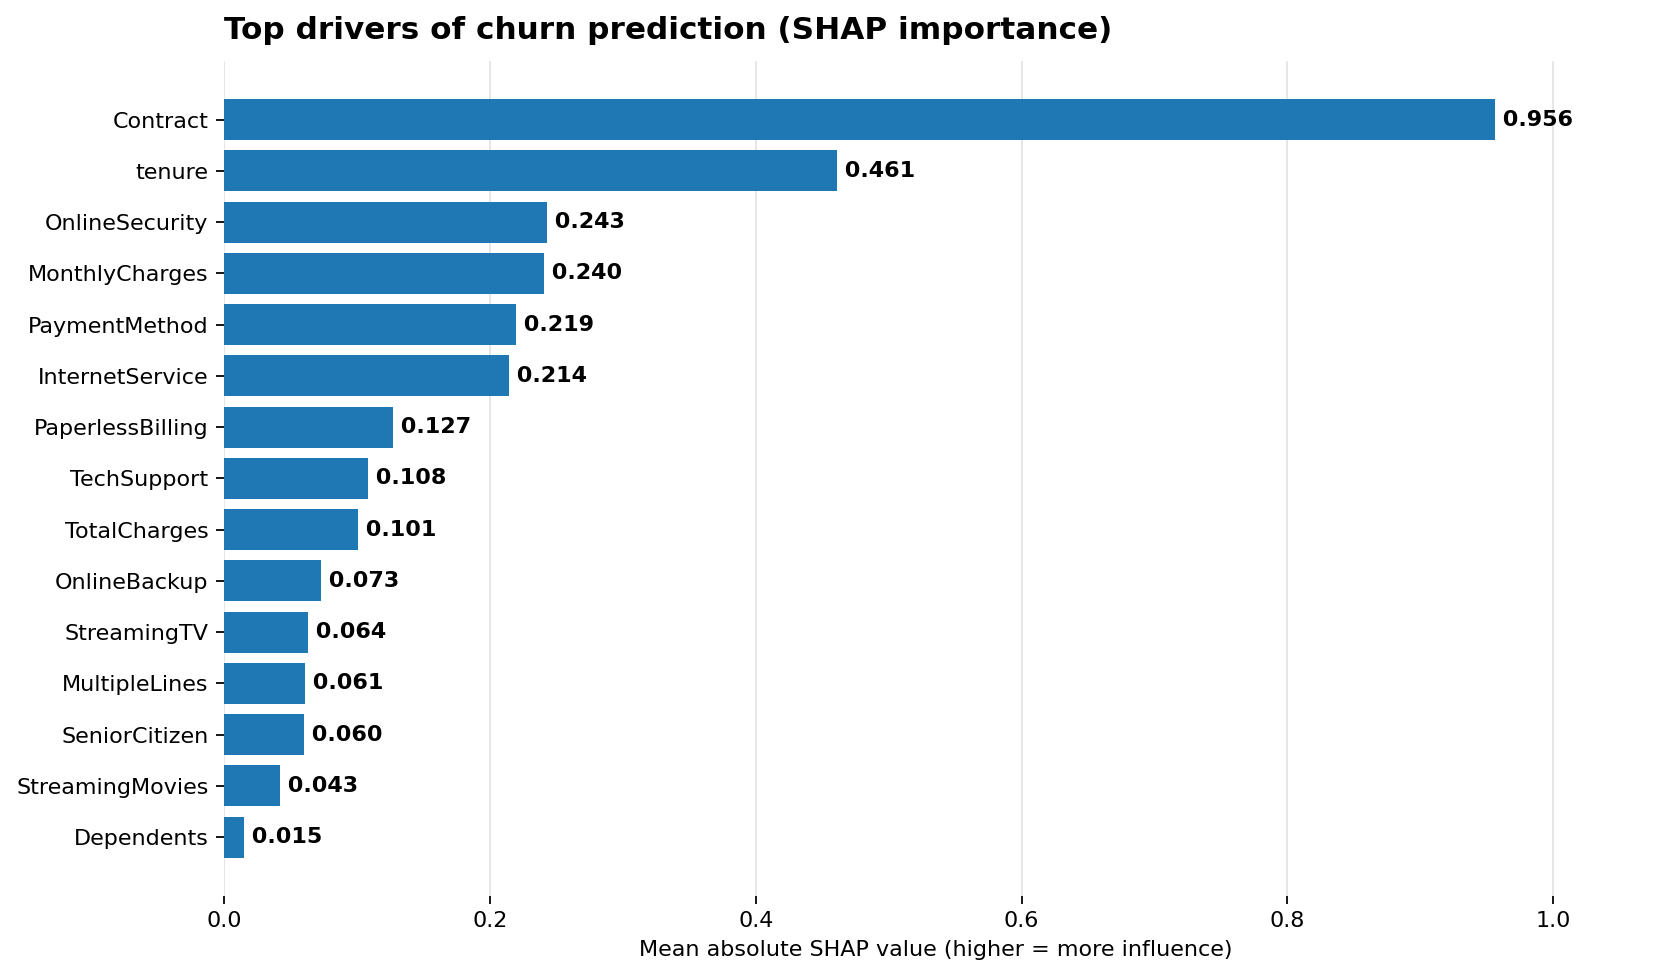

[PLOT] SHAP Top 15 summary
    base_feature  mean_abs_shap
        Contract       0.956426
          tenure       0.461331
  OnlineSecurity       0.243079
  MonthlyCharges       0.240443
   PaymentMethod       0.219337
 InternetService       0.214471
PaperlessBilling       0.127030
     TechSupport       0.108448
    TotalCharges       0.100808
    OnlineBackup       0.073361
     StreamingTV       0.063588
   MultipleLines       0.060717
   SeniorCitizen       0.060013
 StreamingMovies       0.042501
      Dependents       0.014926


In [37]:
print("\nSHAP START")

try:
    import shap
    print("shap_version:", shap.__version__)
except Exception as e:
    print("shap_not_found_installing:", type(e).__name__, str(e))
    import sys
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "shap"])
    import shap
    print("shap_version:", shap.__version__)

pre = best_pipe.named_steps["preprocess"]
mdl = best_pipe.named_steps["model"]

X_test_trans = pre.transform(X_test)

try:
    feature_names = pre.get_feature_names_out()
except Exception:
    feature_names = np.array([f"f{i}" for i in range(X_test_trans.shape[1])])

print("X_test_trans_shape:", X_test_trans.shape)
print("feature_names_count:", len(feature_names))

explainer = shap.TreeExplainer(mdl)
shap_values = explainer.shap_values(X_test_trans)

if isinstance(shap_values, list):
    shap_vals_pos = shap_values[1]
else:
    shap_vals_pos = shap_values

shap_vals_pos = np.array(shap_vals_pos)

print("shap_vals_pos_shape:", shap_vals_pos.shape)

X_test_trans_df = pd.DataFrame(X_test_trans, columns=feature_names)

shap.summary_plot(shap_vals_pos, X_test_trans_df, plot_type="bar", show=False)
plt.title("SHAP summary (bar) on one-hot features")
plt.tight_layout()
plt.show()

shap.summary_plot(shap_vals_pos, X_test_trans_df, show=False)
plt.title("SHAP summary (beeswarm) on one-hot features")
plt.tight_layout()
plt.show()

base_map = []
for name in feature_names:
    s = str(name)
    if s.startswith("num__"):
        base_map.append(s.replace("num__", ""))
    elif s.startswith("cat__"):
        rest = s.replace("cat__", "")
        base = rest.split("_", 1)[0]
        base_map.append(base)
    else:
        base_map.append(s)

base_map = np.array(base_map)

mean_abs = np.mean(np.abs(shap_vals_pos), axis=0)

agg = pd.DataFrame({"base_feature": base_map, "mean_abs_shap": mean_abs})
agg = agg.groupby("base_feature", observed=False)["mean_abs_shap"].sum().sort_values(ascending=False).reset_index()

print("\nTop 20 base features by aggregated mean(|SHAP|):")
print(agg.head(20).to_string(index=False))

plt.figure(figsize=(10, 6))
top = agg.head(15).iloc[::-1]
plt.barh(top["base_feature"], top["mean_abs_shap"])
plt.title("Top 15 features by aggregated mean(|SHAP|)")
plt.xlabel("mean(|SHAP|)")
plt.tight_layout()
plt.show()

print("SHAP END")

plt.figure(figsize=(10.5, 6.2), dpi=160)

top = agg.head(15).copy()
top = top.sort_values("mean_abs_shap", ascending=True)

bars = plt.barh(top["base_feature"], top["mean_abs_shap"])

ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(False)

ax.grid(axis="x", linestyle="-", linewidth=0.8, alpha=0.35)
ax.set_axisbelow(True)

plt.title("Top drivers of churn prediction (SHAP importance)", loc="left", fontsize=14, fontweight="bold", pad=10)
plt.xlabel("Mean absolute SHAP value (higher = more influence)")

xmax = float(top["mean_abs_shap"].max()) if top.shape[0] > 0 else 1.0
plt.xlim(0, xmax * 1.12)

for rect, val in zip(bars, top["mean_abs_shap"].to_numpy(dtype=float)):
    if np.isfinite(val):
        plt.text(val, rect.get_y() + rect.get_height() / 2, f" {val:.3f}", va="center", ha="left", fontsize=10, fontweight="semibold")

plt.tight_layout()
plt.show()

print("[PLOT] SHAP Top 15 summary")
print(top.sort_values("mean_abs_shap", ascending=False).to_string(index=False))

Como o indice SHAP está indicando a variável que tem o maior impacto é Contract seguido por tenure. <br>
Indicando que os contratos de curto prazo durante os primeiros meses são os mais críticos. <br>
Vale uma campanha de retenção para esse segmento. <br>
As pessoas que pagam as maiores mensalidades tendem a cancelar mais. Podemos tentar promoções quando o risco de churn aumentar. <br>
O serviço de segurança a mais é um valor a mais por segurança. Se a pessoa paga por segurança ela acaba ficando mais o que é intuitivo. <br>
Eu achei interessante a questão do serviço de internet de fibra ótica sem suporte técnico que tem uma significancia alta de SHAP e um % de churn alto tbm. Aqui indica a possibilidade de um problema no serviço prestado. <br>
Das variáveis demográficas apenas Senior Citizen ficou com o nível de importancia no Top 15 o que indica um potêncial atendimento personalizado para esse grupo de pessoas. Talvez treinar um callcenter específico para esse grupo.

In [59]:
import numpy as np
import pandas as pd

def impact_topn_with_ltv(
    y_true,
    scores,
    monthly_charges,
    top_n,
    uplift_values=(0.05, 0.10, 0.15),
    cost_per_customer=20.0,
    margin=1.0,
    months_retained_values=(3, 6, 12),
):
    y_true = np.array(y_true, dtype=int)
    scores = np.array(scores, dtype=float)
    monthly_charges = np.array(monthly_charges, dtype=float)

    idx = np.argsort(-scores)
    top_idx = idx[:int(top_n)]

    N = int(len(top_idx))
    p0 = float(y_true[top_idx].mean())
    arpu = float(monthly_charges[top_idx].mean())

    rows = []
    for months_retained in months_retained_values:
        for u in uplift_values:
            churn_avoided = N * p0 * float(u)
            gross_retained = churn_avoided * (arpu * float(margin) * float(months_retained))
            total_cost = N * float(cost_per_customer)
            net = gross_retained - total_cost

            rows.append({
                "TopN": N,
                "p0_churn_base": p0,
                "arpu_monthly": arpu,
                "months_retained": int(months_retained),
                "uplift_rel_reduction": float(u),
                "churn_avoided": churn_avoided,
                "gross_retained_value": gross_retained,
                "total_cost": total_cost,
                "net_impact": net,
            })

    out = pd.DataFrame(rows).sort_values(["months_retained", "uplift_rel_reduction"])
    return out

proba_all = best_pipe.predict_proba(X)[:, 1]
top_n = int(np.ceil(0.10 * len(X)))

impact_all = impact_topn_with_ltv(
    y_true=y.values,
    scores=proba_all,
    monthly_charges=X["MonthlyCharges"].values,
    top_n=top_n,
    uplift_values=(0.05, 0.10, 0.15),
    cost_per_customer=20.0,
    margin=1.0,
    months_retained_values=(3, 6, 12),
)

print("TopN used:", top_n, "of", len(X))
print(impact_all.to_string(index=False))

TopN used: 705 of 7043
 TopN  p0_churn_base  arpu_monthly  months_retained  uplift_rel_reduction  churn_avoided  gross_retained_value  total_cost  net_impact
  705            0.8     80.462695                3                  0.05           28.2              6807.144     14100.0   -7292.856
  705            0.8     80.462695                3                  0.10           56.4             13614.288     14100.0    -485.712
  705            0.8     80.462695                3                  0.15           84.6             20421.432     14100.0    6321.432
  705            0.8     80.462695                6                  0.05           28.2             13614.288     14100.0    -485.712
  705            0.8     80.462695                6                  0.10           56.4             27228.576     14100.0   13128.576
  705            0.8     80.462695                6                  0.15           84.6             40842.864     14100.0   26742.864
  705            0.8     80.4626